In [1]:
# ============================================================
# CELL 1: IMPORTS AND CONFIGURATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# Sklearn metrics
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score, accuracy_score)
from sklearn.model_selection import train_test_split

# Progress bar
from tqdm import tqdm

# ── Paths ──────────────────────────────────────────────────
DATASET_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\archive"
PROJECT_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project"
MODELS_PATH  = os.path.join(PROJECT_PATH, "models")
RESULTS_PATH = os.path.join(PROJECT_PATH, "results")

# ── Hyperparameters (exact values from paper) ──────────────
IMG_SIZE     = 64        # resize to 64x64
BATCH_SIZE   = 64        # data loading batch size
TRAIN_BATCH  = 32        # training batch size (paper uses 32)
EPOCHS       = 10        # early stopping at 10 epochs
LR           = 0.0001    # Adam learning rate
SEED         = 42

# ── ImageNet normalization (from paper) ────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Device ────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"  Device        : {device}")
print(f"  GPU Name      : {torch.cuda.get_device_name(0)}")
print(f"  VRAM Total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"  PyTorch       : {torch.__version__}")
print(f"  Dataset Path  : {DATASET_PATH}")
print(f"  Project Path  : {PROJECT_PATH}")
print("=" * 50)
print("✅ All imports successful!")

  Device        : cuda
  GPU Name      : NVIDIA GeForce RTX 4060
  VRAM Total    : 8.59 GB
  PyTorch       : 2.5.1+cu121
  Dataset Path  : C:\Users\DYPIU\Desktop\Hafsa\archive
  Project Path  : C:\Users\DYPIU\Desktop\Hafsa\IDC_Project
✅ All imports successful!


🔍 Scanning dataset... this may take a minute...
   Found 280 patient folders


Scanning patients: 100%|██████████████████████████████████████████| 280/280 [00:00<00:00, 387.81it/s]



  DATASET SUMMARY
  Total images     : 277,524
  Benign  (class 0): 198,738  (71.6%)
  Malignant (class 1): 78,786  (28.4%)
  Class imbalance ratio: 2.52:1


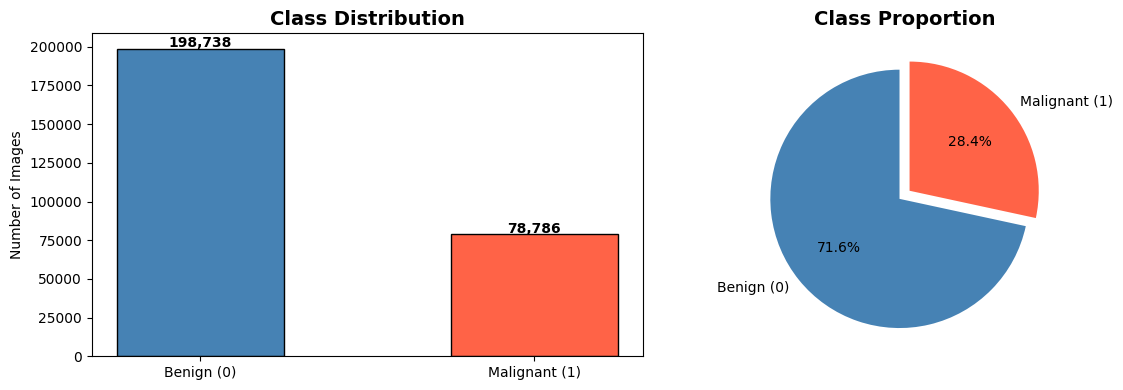

✅ Plot saved to: C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\training_plots\class_distribution.png


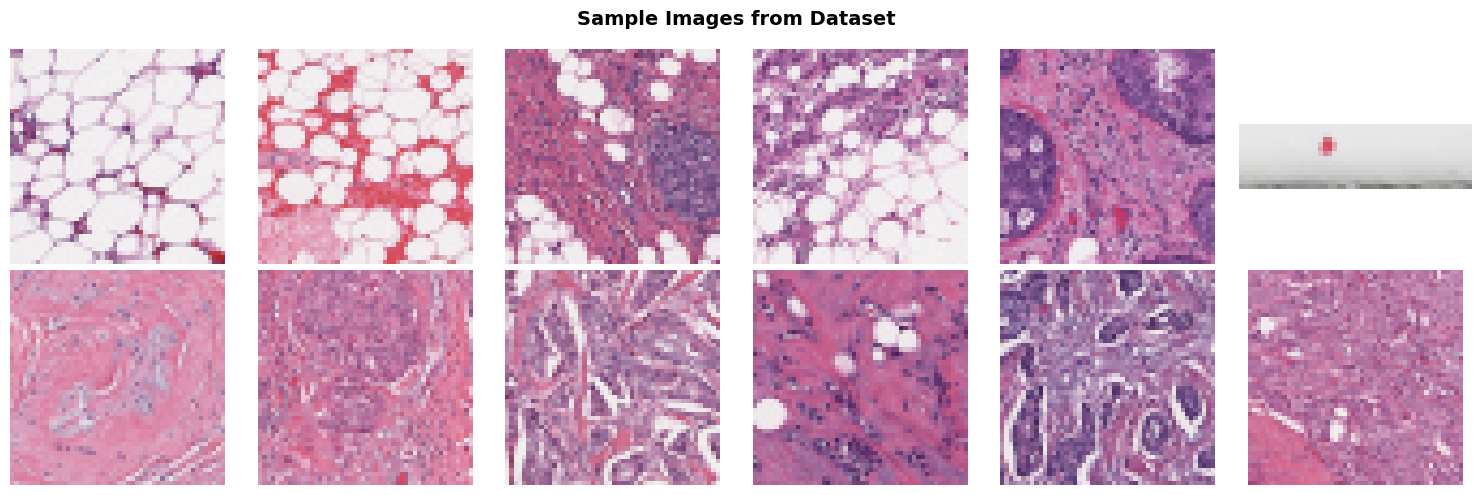

✅ Sample images saved to: C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\training_plots\sample_images.png

✅ Cell 2 complete! DataFrame ready with 277,524 images.


In [2]:
# ============================================================
# CELL 2: DATASET LOADING AND EXPLORATION
# ============================================================

print("🔍 Scanning dataset... this may take a minute...")

# ── Collect all image paths and labels ────────────────────
all_images = []
all_labels = []

patient_dirs = [d for d in os.listdir(DATASET_PATH)
                if os.path.isdir(os.path.join(DATASET_PATH, d))]

print(f"   Found {len(patient_dirs)} patient folders")

for patient in tqdm(patient_dirs, desc="Scanning patients"):
    patient_path = os.path.join(DATASET_PATH, patient)
    for label in ['0', '1']:
        class_path = os.path.join(patient_path, label)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith('.png'):
                    all_images.append(os.path.join(class_path, img_file))
                    all_labels.append(int(label))

# ── Build DataFrame ───────────────────────────────────────
df = pd.DataFrame({'path': all_images, 'label': all_labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ── Statistics ────────────────────────────────────────────
total       = len(df)
n_benign    = (df['label'] == 0).sum()
n_malignant = (df['label'] == 1).sum()

print("\n" + "=" * 50)
print("  DATASET SUMMARY")
print("=" * 50)
print(f"  Total images     : {total:,}")
print(f"  Benign  (class 0): {n_benign:,}  ({n_benign/total*100:.1f}%)")
print(f"  Malignant (class 1): {n_malignant:,}  ({n_malignant/total*100:.1f}%)")
print(f"  Class imbalance ratio: {n_benign/n_malignant:.2f}:1")
print("=" * 50)

# ── Visualize class distribution ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Benign (0)', 'Malignant (1)'],
            [n_benign, n_malignant],
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate([n_benign, n_malignant]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([n_benign, n_malignant],
            labels=['Benign (0)', 'Malignant (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'training_plots', 'class_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to: {save_path}")

# ── Show sample images ────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')

for col in range(6):
    for row, label in enumerate([0, 1]):
        sample = df[df['label'] == label].iloc[col]
        img = Image.open(sample['path']).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(
                'Benign' if label == 0 else 'Malignant',
                fontsize=11, fontweight='bold',
                color='steelblue' if label == 0 else 'tomato')

plt.tight_layout()
save_path2 = os.path.join(RESULTS_PATH, 'training_plots', 'sample_images.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Sample images saved to: {save_path2}")
print(f"\n✅ Cell 2 complete! DataFrame ready with {total:,} images.")

In [3]:
# ============================================================
# CELL 3: TRAIN/TEST SPLIT AND DATA LOADERS
# ============================================================

from sklearn.model_selection import train_test_split

# ── Stratified 80/20 split (exactly as in paper) ──────────
train_df, test_df = train_test_split(
    df, test_size=0.20,
    random_state=SEED,
    stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("=" * 50)
print("  TRAIN / TEST SPLIT")
print("=" * 50)
print(f"  Train samples : {len(train_df):,}  (80%)")
print(f"    Benign      : {(train_df['label']==0).sum():,}")
print(f"    Malignant   : {(train_df['label']==1).sum():,}")
print(f"  Test samples  : {len(test_df):,}  (20%)")
print(f"    Benign      : {(test_df['label']==0).sum():,}")
print(f"    Malignant   : {(test_df['label']==1).sum():,}")
print("=" * 50)

# ── Custom Dataset Class ───────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label    = self.df.loc[idx, 'label']
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ── Transforms (paper: resize 64x64, center crop, normalize) ──
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ── Datasets ──────────────────────────────────────────────
train_dataset = IDCDataset(train_df, transform=train_transform)
test_dataset  = IDCDataset(test_df,  transform=test_transform)

# ── Class weights for weighted loss (paper method) ─────────
n_train      = len(train_df)
n_benign_tr  = (train_df['label'] == 0).sum()
n_malig_tr   = (train_df['label'] == 1).sum()
weight_benign   = n_train / (2 * n_benign_tr)
weight_malignant= n_train / (2 * n_malig_tr)
class_weights   = torch.tensor([weight_benign, weight_malignant],
                                dtype=torch.float).to(device)

print(f"\n  Class Weights (for weighted loss):")
print(f"    Benign    weight : {weight_benign:.4f}")
print(f"    Malignant weight : {weight_malignant:.4f}")

# ── DataLoaders ────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH,
    shuffle=True,
    num_workers=0,      # ← changed from 4 to 0 (fixes Windows hanging)
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TRAIN_BATCH,
    shuffle=False,
    num_workers=0,      # ← changed from 4 to 0
    pin_memory=True
)

print(f"\n  Train batches : {len(train_loader):,}")
print(f"  Test batches  : {len(test_loader):,}")

# ── Verify one batch ───────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"\n  Sample batch:")
print(f"    Image tensor shape : {images.shape}")
print(f"    Label tensor shape : {labels.shape}")
print(f"    Image dtype        : {images.dtype}")
print(f"    Min / Max values   : {images.min():.3f} / {images.max():.3f}")
print(f"\n✅ Cell 3 complete! Data loaders ready.")

  TRAIN / TEST SPLIT
  Train samples : 222,019  (80%)
    Benign      : 158,990
    Malignant   : 63,029
  Test samples  : 55,505  (20%)
    Benign      : 39,748
    Malignant   : 15,757

  Class Weights (for weighted loss):
    Benign    weight : 0.6982
    Malignant weight : 1.7612

  Train batches : 6,939
  Test batches  : 1,735

  Sample batch:
    Image tensor shape : torch.Size([32, 3, 64, 64])
    Label tensor shape : torch.Size([32])
    Image dtype        : torch.float32
    Min / Max values   : -1.878 / 2.518

✅ Cell 3 complete! Data loaders ready.


In [4]:
# ============================================================
# CELL 4: BASELINE CNN MODEL ARCHITECTURE
# ============================================================

class ConvBlock(nn.Module):
    """Single convolutional block: Conv -> BN -> ReLU -> MaxPool"""
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.block(x)


class BaseCNN(nn.Module):
    """
    4-block CNN from paper:
    Filter sizes: 32 -> 64 -> 128 -> 256
    Followed by Global Average Pooling
    FC layers: 128 -> 2 (softmax)
    """
    def __init__(self, num_classes=2):
        super(BaseCNN, self).__init__()

        # 4 convolutional blocks (increasing filter sizes)
        self.features = nn.Sequential(
            ConvBlock(3,   32),    # Block 1: 64x64 -> 32x32
            ConvBlock(32,  64),    # Block 2: 32x32 -> 16x16
            ConvBlock(64,  128),   # Block 3: 16x16 -> 8x8
            ConvBlock(128, 256),   # Block 4: 8x8   -> 4x4
        )

        # Global Average Pooling (4x4 -> 1x1)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ── Instantiate and inspect ────────────────────────────────
model_cnn = BaseCNN(num_classes=2).to(device)

# Count parameters
total_params     = sum(p.numel() for p in model_cnn.parameters())
trainable_params = sum(p.numel() for p in model_cnn.parameters()
                       if p.requires_grad)

print("=" * 50)
print("  BASELINE CNN ARCHITECTURE")
print("=" * 50)
print(model_cnn)
print("=" * 50)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")

# ── Verify forward pass with dummy input ───────────────────
dummy = torch.randn(4, 3, 64, 64).to(device)
with torch.no_grad():
    out = model_cnn(dummy)

print(f"\n  Forward pass check:")
print(f"    Input  shape : {dummy.shape}")
print(f"    Output shape : {out.shape}  ← should be [4, 2]")
print(f"\n✅ Cell 4 complete! CNN model ready on {device}.")

  BASELINE CNN ARCHITECTURE
BaseCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2)

In [5]:
# ============================================================
# CELL 5: TRAINING HELPER FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch, return avg loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    loop = tqdm(loader, desc="  Training", leave=False)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

        loop.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total:.2f}%")

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evaluate model, return loss, accuracy, predictions, labels."""
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0
    all_preds    = []
    all_labels   = []
    all_probs    = []

    with torch.no_grad():
        loop = tqdm(loader, desc="  Evaluating", leave=False)
        for images, labels in loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs      = model(images)
            loss         = criterion(outputs, labels)
            probs        = F.softmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


def full_train(model, train_loader, test_loader,
               optimizer, criterion, epochs,
               device, model_name="model"):
    """Full training loop with per-epoch logging and best model saving."""

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}
    best_acc   = 0.0
    best_path  = os.path.join(MODELS_PATH, f"{model_name}_best.pth")

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"  Epochs: {epochs}  |  Device: {device}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        print(f"\n  Epoch [{epoch}/{epochs}]")

        # Train
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device)

        # Validate
        vl_loss, vl_acc, _, _, _ = evaluate(
            model, test_loader, criterion, device)

        # Log
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"    Train Loss: {tr_loss:.4f}  |  Train Acc: {tr_acc*100:.2f}%")
        print(f"    Val   Loss: {vl_loss:.4f}  |  Val   Acc: {vl_acc*100:.2f}%")

        # Save best model
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), best_path)
            print(f"    ✅ Best model saved → {best_acc*100:.2f}%")

    print(f"\n{'='*55}")
    print(f"  Training complete! Best Val Acc: {best_acc*100:.2f}%")
    print(f"  Model saved to: {best_path}")
    print(f"{'='*55}")
    return history


def plot_history(history, model_name="model"):
    """Plot and save training/validation accuracy and loss curves."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves',
                 fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs, [a*100 for a in history['train_acc']],
                 'b-o', label='Train Acc', linewidth=2)
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],
                 'r-o', label='Val Acc', linewidth=2)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(epochs)

    # Loss
    axes[1].plot(epochs, history['train_loss'],
                 'b-o', label='Train Loss', linewidth=2)
    axes[1].plot(epochs, history['val_loss'],
                 'r-o', label='Val Loss', linewidth=2)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(epochs)

    plt.tight_layout()
    save_path = os.path.join(RESULTS_PATH, 'training_plots',
                             f'{model_name}_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Training curves saved → {save_path}")


def plot_confusion_matrix(all_labels, all_preds, model_name="model"):
    """Plot and save confusion matrix."""
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'{model_name} — Confusion Matrix',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_PATH, 'confusion_matrix',
                             f'{model_name}_cm.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Confusion matrix saved → {save_path}")


def plot_roc_curve(all_labels, all_probs, model_name="model"):
    """Plot and save ROC curve with AUC score."""
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc     = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{model_name} — ROC Curve',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_PATH, 'roc_curve',
                             f'{model_name}_roc.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ ROC curve saved → {save_path}")


def print_classification_report(all_labels, all_preds,
                                 model_name="model"):
    """Print and save classification report."""
    report = classification_report(
        all_labels, all_preds,
        target_names=['Benign (0)', 'Malignant (1)'],
        digits=4
    )
    print(f"\n  Classification Report — {model_name}")
    print("  " + "="*52)
    print(report)

    save_path = os.path.join(RESULTS_PATH, 'classification_report',
                             f'{model_name}_report.txt')
    with open(save_path, 'w') as f:
        f.write(f"Classification Report — {model_name}\n")
        f.write("="*52 + "\n")
        f.write(report)
    print(f"  ✅ Report saved → {save_path}")


print("✅ Cell 5 complete! All helper functions defined.")
print("   Functions ready:")
print("   • train_one_epoch()         — trains one epoch")
print("   • evaluate()                — evaluates model")
print("   • full_train()              — full training loop")
print("   • plot_history()            — accuracy/loss curves")
print("   • plot_confusion_matrix()   — confusion matrix")
print("   • plot_roc_curve()          — ROC + AUC")
print("   • print_classification_report() — metrics report")

✅ Cell 5 complete! All helper functions defined.
   Functions ready:
   • train_one_epoch()         — trains one epoch
   • evaluate()                — evaluates model
   • full_train()              — full training loop
   • plot_history()            — accuracy/loss curves
   • plot_confusion_matrix()   — confusion matrix
   • plot_roc_curve()          — ROC + AUC
   • print_classification_report() — metrics report


Starting Baseline CNN Training...
Expected accuracy: ~89% (as per paper)
This will take ~25-35 minutes on RTX 4060


  Training: BaseCNN
  Epochs: 10  |  Device: cuda

  Epoch [1/10]


    Train Loss: 0.3284  |  Train Acc: 86.14%
    Val   Loss: 0.2940  |  Val   Acc: 87.48%
    ✅ Best model saved → 87.48%

  Epoch [2/10]


    Train Loss: 0.2991  |  Train Acc: 87.39%
    Val   Loss: 0.2879  |  Val   Acc: 87.70%
    ✅ Best model saved → 87.70%

  Epoch [3/10]


    Train Loss: 0.2889  |  Train Acc: 87.88%
    Val   Loss: 0.2745  |  Val   Acc: 88.37%
    ✅ Best model saved → 88.37%

  Epoch [4/10]


    Train Loss: 0.2810  |  Train Acc: 88.18%
    Val   Loss: 0.2679  |  Val   Acc: 88.57%
    ✅ Best model saved → 88.57%

  Epoch [5/10]


...

    Train Loss: 0.2673  |  Train Acc: 88.81%
    Val   Loss: 0.2607  |  Val   Acc: 89.07%
    ✅ Best model saved → 89.07%

  Epoch [7/10]


    Train Loss: 0.2624  |  Train Acc: 89.01%
    Val   Loss: 0.2613  |  Val   Acc: 88.95%

  Epoch [8/10]


    Train Loss: 0.2571  |  Train Acc: 89.21%
    Val   Loss: 0.2559  |  Val   Acc: 89.27%
    ✅ Best model saved → 89.27%

  Epoch [9/10]


    Train Loss: 0.2517  |  Train Acc: 89.49%
    Val   Loss: 0.2583  |  Val   Acc: 89.14%

  Epoch [10/10]


    Train Loss: 0.2460  |  Train Acc: 89.76%
    Val   Loss: 0.2478  |  Val   Acc: 89.49%
    ✅ Best model saved → 89.49%

  Training complete! Best Val Acc: 89.49%
  Model saved to: C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models\BaseCNN_best.pth


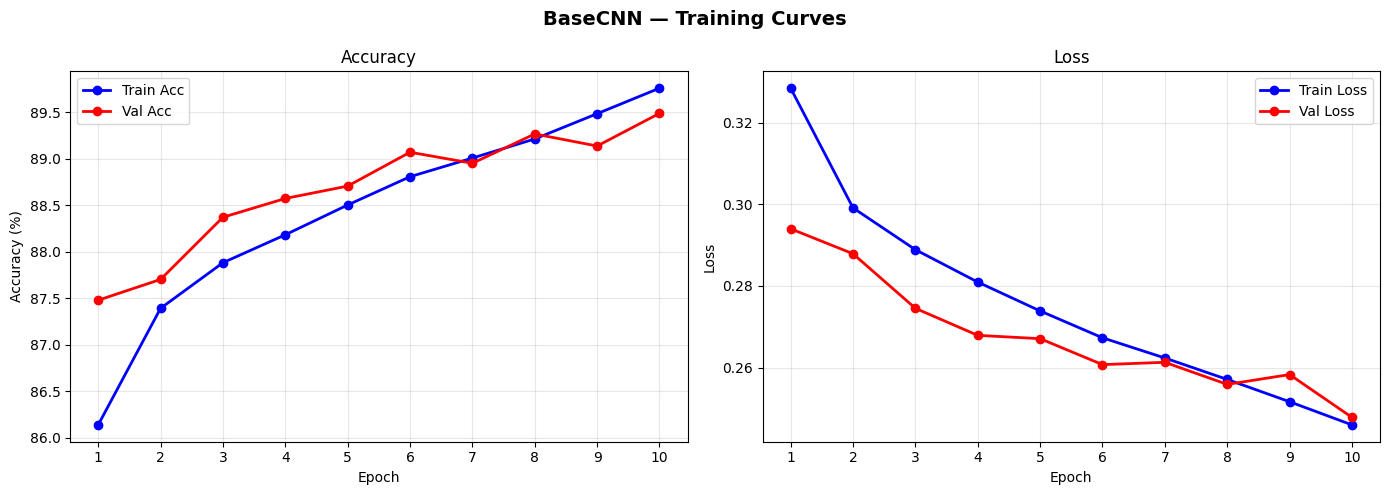

  ✅ Training curves saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\training_plots\BaseCNN_curves.png

Final Evaluation on Test Set...



Test Accuracy : 89.49%


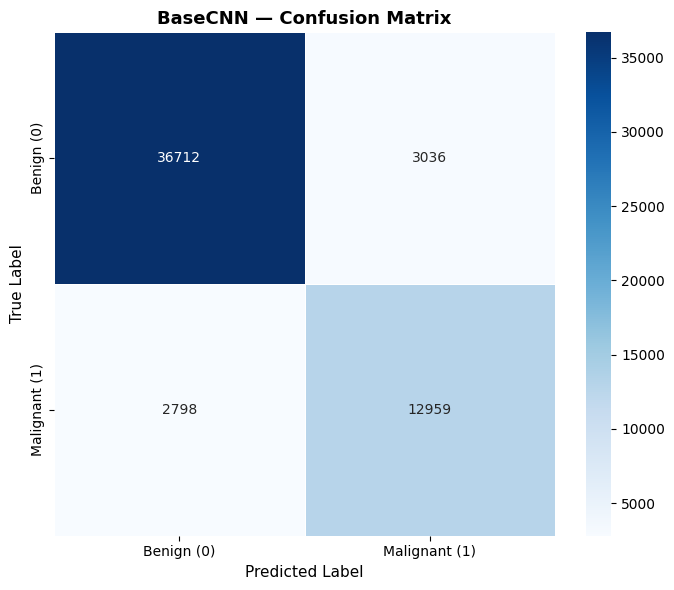

  ✅ Confusion matrix saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\confusion_matrix\BaseCNN_cm.png


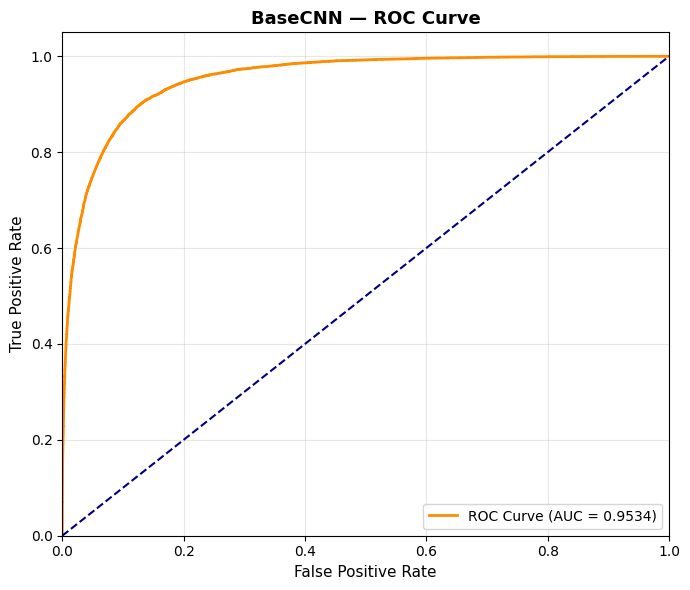

  ✅ ROC curve saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\roc_curve\BaseCNN_roc.png

  Classification Report — BaseCNN
               precision    recall  f1-score   support

   Benign (0)     0.9292    0.9236    0.9264     39748
Malignant (1)     0.8102    0.8224    0.8163     15757

     accuracy                         0.8949     55505
    macro avg     0.8697    0.8730    0.8713     55505
 weighted avg     0.8954    0.8949    0.8951     55505

  ✅ Report saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\classification_report\BaseCNN_report.txt

Cell 6 Complete — Baseline CNN done!
Final Test Accuracy: 89.49%
Target from paper : 89.00%


In [8]:
# ============================================================
# CELL 6: TRAIN BASELINE CNN (MODEL 1 — No class balancing)
# ============================================================

print("Starting Baseline CNN Training...")
print("Expected accuracy: ~89% (as per paper)")
print("This will take ~25-35 minutes on RTX 4060\n")

# Fresh model instance
model_cnn = BaseCNN(num_classes=2).to(device)

# Loss: standard cross entropy (no weighting)
criterion_base = nn.CrossEntropyLoss()

# Optimizer: Adam lr=0.0001 (exactly as in paper)
optimizer_base = optim.Adam(model_cnn.parameters(), lr=LR)

# Train
history_base = full_train(
    model        = model_cnn,
    train_loader = train_loader,
    test_loader  = test_loader,
    optimizer    = optimizer_base,
    criterion    = criterion_base,
    epochs       = EPOCHS,
    device       = device,
    model_name   = "BaseCNN"
)

# Plot training curves
plot_history(history_base, model_name="BaseCNN")

# Final evaluation on test set
print("\nFinal Evaluation on Test Set...")
model_cnn.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, "BaseCNN_best.pth"))
)

_, test_acc, test_preds, test_labels, test_probs = evaluate(
    model_cnn, test_loader, criterion_base, device
)

print(f"\nTest Accuracy : {test_acc*100:.2f}%")

# Confusion matrix
plot_confusion_matrix(test_labels, test_preds, model_name="BaseCNN")

# ROC Curve
plot_roc_curve(test_labels, test_probs, model_name="BaseCNN")

# Classification report
print_classification_report(test_labels, test_preds, model_name="BaseCNN")

print("\n" + "="*55)
print("Cell 6 Complete — Baseline CNN done!")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print("Target from paper : 89.00%")
print("="*55)

Starting CNN + Weighted Loss Training...
Expected accuracy: ~86% (slight dip is expected per paper)
This will take ~25-35 minutes on RTX 4060

Class weights applied:
  Benign    : 0.6982
  Malignant : 1.7612


  Training: CNN_Weighted
  Epochs: 10  |  Device: cuda

  Epoch [1/10]


    Train Loss: 0.3695  |  Train Acc: 84.42%
    Val   Loss: 0.3332  |  Val   Acc: 86.21%
    ✅ Best model saved → 86.21%

  Epoch [2/10]


    Train Loss: 0.3345  |  Train Acc: 85.93%
    Val   Loss: 0.3173  |  Val   Acc: 86.60%
    ✅ Best model saved → 86.60%

  Epoch [3/10]


    Train Loss: 0.3211  |  Train Acc: 86.44%
    Val   Loss: 0.3197  |  Val   Acc: 84.59%

  Epoch [4/10]


    Train Loss: 0.3120  |  Train Acc: 86.76%
    Val   Loss: 0.3108  |  Val   Acc: 85.10%

  Epoch [5/10]


...

    Train Loss: 0.2951  |  Train Acc: 87.33%
    Val   Loss: 0.2840  |  Val   Acc: 87.38%
    ✅ Best model saved → 87.38%

  Epoch [7/10]


    Train Loss: 0.2888  |  Train Acc: 87.61%
    Val   Loss: 0.2892  |  Val   Acc: 86.81%

  Epoch [8/10]


    Train Loss: 0.2831  |  Train Acc: 87.95%
    Val   Loss: 0.3369  |  Val   Acc: 81.69%

  Epoch [9/10]


    Train Loss: 0.2768  |  Train Acc: 88.10%
    Val   Loss: 0.2834  |  Val   Acc: 86.79%

  Epoch [10/10]


    Train Loss: 0.2716  |  Train Acc: 88.35%
    Val   Loss: 0.2746  |  Val   Acc: 87.87%
    ✅ Best model saved → 87.87%

  Training complete! Best Val Acc: 87.87%
  Model saved to: C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models\CNN_Weighted_best.pth


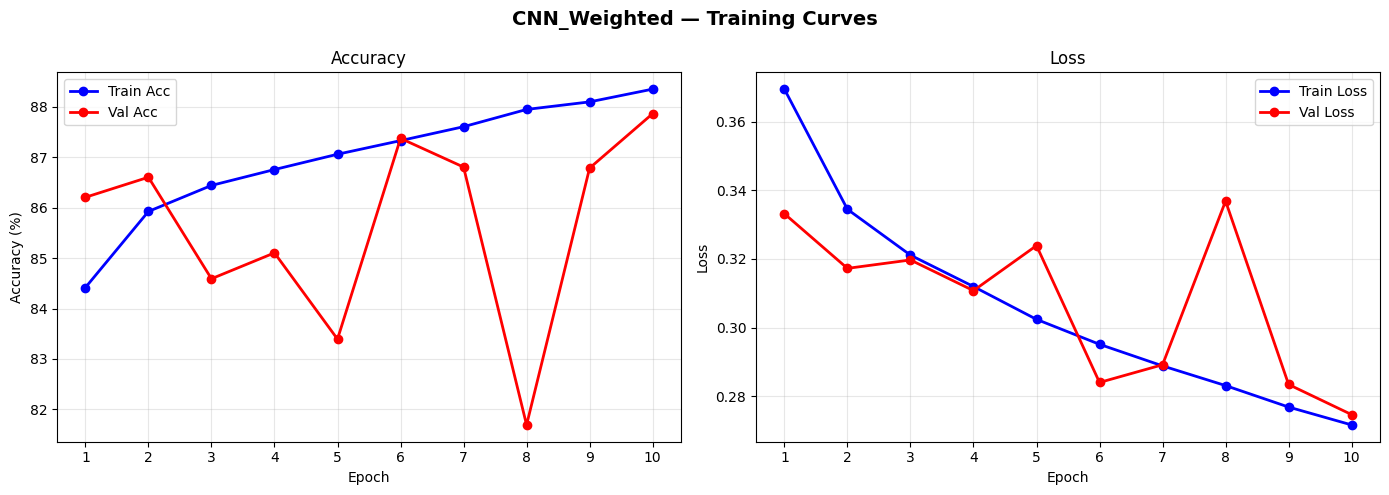

  ✅ Training curves saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\training_plots\CNN_Weighted_curves.png

Final Evaluation on Test Set...



Test Accuracy : 87.87%


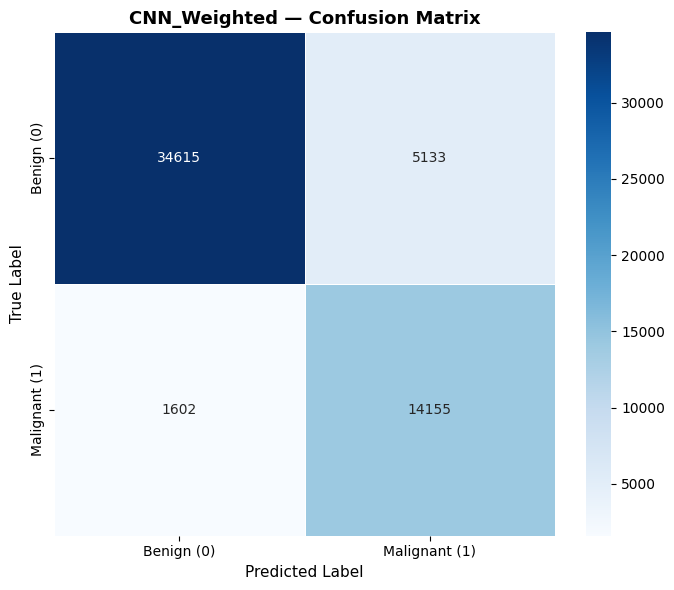

  ✅ Confusion matrix saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\confusion_matrix\CNN_Weighted_cm.png


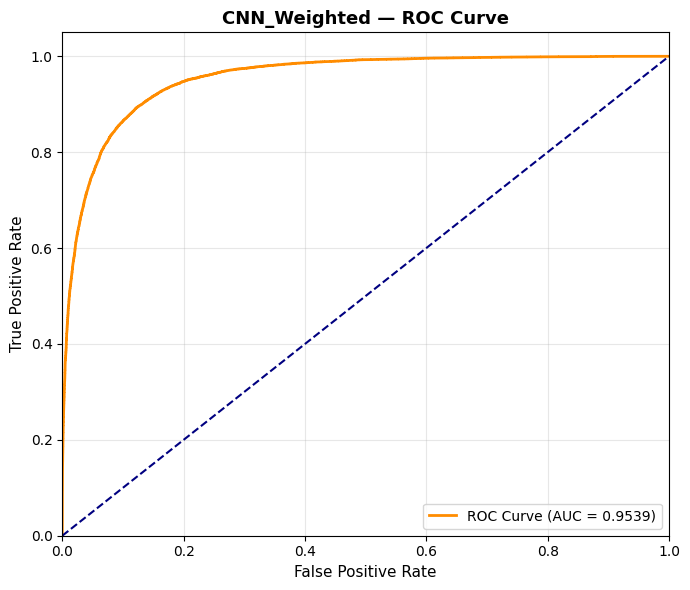

  ✅ ROC curve saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\roc_curve\CNN_Weighted_roc.png

  Classification Report — CNN_Weighted
               precision    recall  f1-score   support

   Benign (0)     0.9558    0.8709    0.9113     39748
Malignant (1)     0.7339    0.8983    0.8078     15757

     accuracy                         0.8787     55505
    macro avg     0.8448    0.8846    0.8596     55505
 weighted avg     0.8928    0.8787    0.8820     55505

  ✅ Report saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\classification_report\CNN_Weighted_report.txt

  MODEL COMPARISON SO FAR
  BaseCNN accuracy          : 89.49%
  CNN + Weighted Loss       : 87.87%
  Paper BaseCNN target      : 89.00%
  Paper Weighted Loss target: 86.00%
Cell 7 Complete!


In [9]:
# ============================================================
# CELL 7: CNN WITH WEIGHTED LOSS (MODEL 2)
# ============================================================

print("Starting CNN + Weighted Loss Training...")
print("Expected accuracy: ~86% (slight dip is expected per paper)")
print("This will take ~25-35 minutes on RTX 4060\n")

# Fresh model instance
model_weighted = BaseCNN(num_classes=2).to(device)

# Loss: weighted cross entropy to handle class imbalance
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer: Adam lr=0.0001
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=LR)

print(f"Class weights applied:")
print(f"  Benign    : {class_weights[0]:.4f}")
print(f"  Malignant : {class_weights[1]:.4f}\n")

# Train
history_weighted = full_train(
    model        = model_weighted,
    train_loader = train_loader,
    test_loader  = test_loader,
    optimizer    = optimizer_weighted,
    criterion    = criterion_weighted,
    epochs       = EPOCHS,
    device       = device,
    model_name   = "CNN_Weighted"
)

# Plot training curves
plot_history(history_weighted, model_name="CNN_Weighted")

# Final evaluation on test set
print("\nFinal Evaluation on Test Set...")
model_weighted.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, "CNN_Weighted_best.pth"))
)

_, test_acc_w, test_preds_w, test_labels_w, test_probs_w = evaluate(
    model_weighted, test_loader, criterion_weighted, device
)

print(f"\nTest Accuracy : {test_acc_w*100:.2f}%")

# Confusion matrix
plot_confusion_matrix(test_labels_w, test_preds_w, model_name="CNN_Weighted")

# ROC Curve
plot_roc_curve(test_labels_w, test_probs_w, model_name="CNN_Weighted")

# Classification report
print_classification_report(test_labels_w, test_preds_w, model_name="CNN_Weighted")

# Comparison with baseline
print("\n" + "="*55)
print("  MODEL COMPARISON SO FAR")
print("="*55)
print(f"  BaseCNN accuracy          : 89.49%")
print(f"  CNN + Weighted Loss       : {test_acc_w*100:.2f}%")
print(f"  Paper BaseCNN target      : 89.00%")
print(f"  Paper Weighted Loss target: 86.00%")
print("="*55)
print("Cell 7 Complete!")

Starting VGG19 Transfer Learning (Paper Version)...
Expected accuracy: ~90% (as per paper)
This will take ~35-45 minutes on RTX 4060



Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\DYPIU/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|█████████████████████████████████████████████████████████████| 548M/548M [00:06<00:00, 84.2MB/s]


VGG19 Parameter Summary:
  Total parameters     : 32,935,874
  Trainable parameters : 22,350,722
  Frozen parameters    : 10,585,152


  Training: VGG19_Paper
  Epochs: 10  |  Device: cuda

  Epoch [1/10]


    Train Loss: 0.3194  |  Train Acc: 86.66%
    Val   Loss: 0.2963  |  Val   Acc: 87.32%
    ✅ Best model saved → 87.32%

  Epoch [2/10]


    Train Loss: 0.2880  |  Train Acc: 87.96%
    Val   Loss: 0.2979  |  Val   Acc: 87.51%
    ✅ Best model saved → 87.51%

  Epoch [3/10]


...

    Train Loss: 0.1666  |  Train Acc: 93.31%
    Val   Loss: 0.3955  |  Val   Acc: 87.53%

  Epoch [7/10]


    Train Loss: 0.1316  |  Train Acc: 94.87%
    Val   Loss: 0.5008  |  Val   Acc: 87.02%

  Epoch [8/10]


    Train Loss: 0.1052  |  Train Acc: 95.91%
    Val   Loss: 0.5654  |  Val   Acc: 86.20%

  Epoch [9/10]


    Train Loss: 0.0911  |  Train Acc: 96.76%
    Val   Loss: 0.5902  |  Val   Acc: 86.76%

  Epoch [10/10]


    Train Loss: 0.0666  |  Train Acc: 97.47%
    Val   Loss: 0.7060  |  Val   Acc: 86.64%

  Training complete! Best Val Acc: 87.94%
  Model saved to: C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models\VGG19_Paper_best.pth


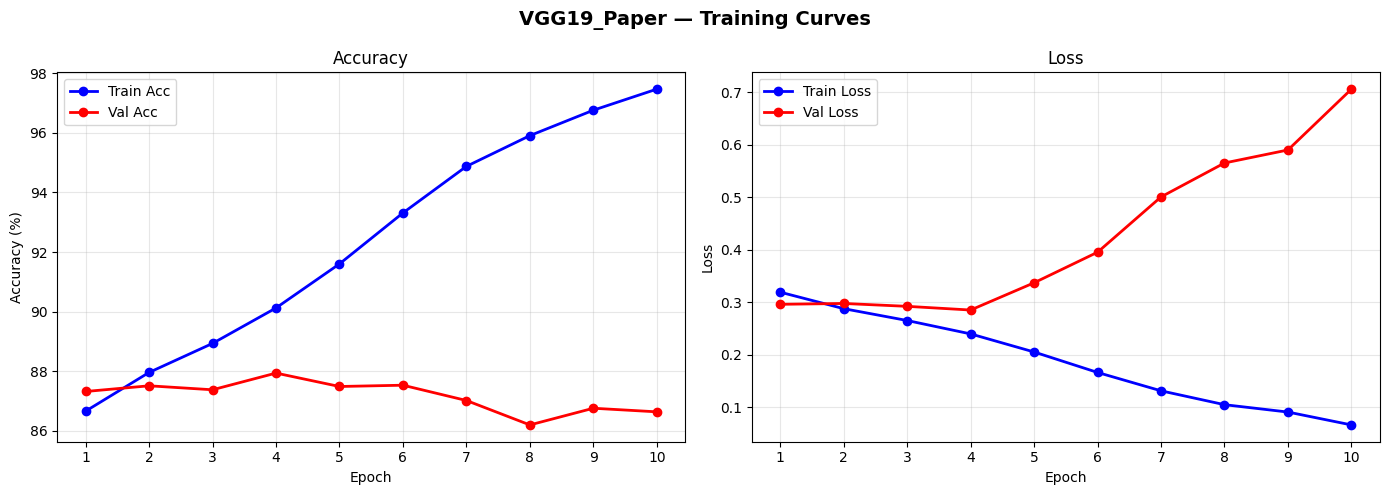

  ✅ Training curves saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\training_plots\VGG19_Paper_curves.png

Final Evaluation on Test Set...



Test Accuracy : 87.94%


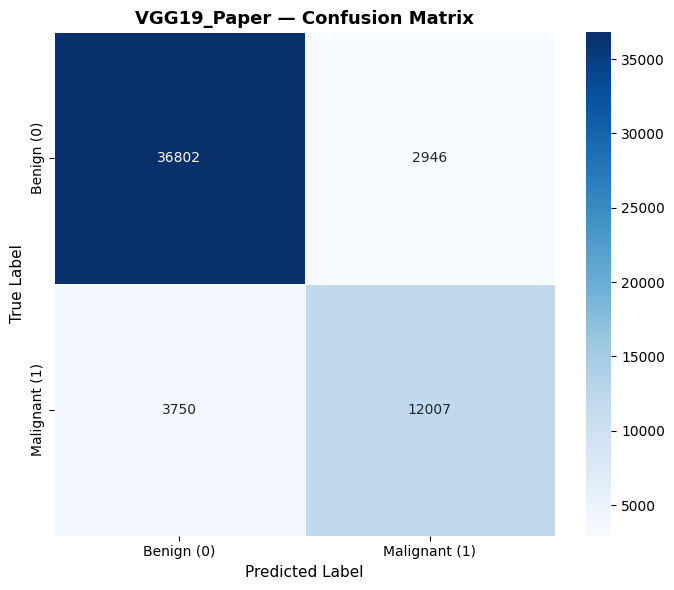

  ✅ Confusion matrix saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\confusion_matrix\VGG19_Paper_cm.png


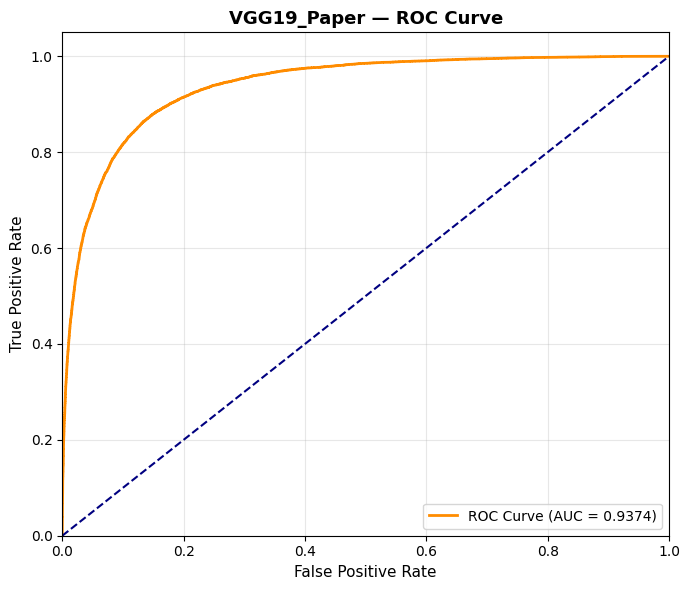

  ✅ ROC curve saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\roc_curve\VGG19_Paper_roc.png

  Classification Report — VGG19_Paper
               precision    recall  f1-score   support

   Benign (0)     0.9075    0.9259    0.9166     39748
Malignant (1)     0.8030    0.7620    0.7820     15757

     accuracy                         0.8794     55505
    macro avg     0.8553    0.8439    0.8493     55505
 weighted avg     0.8778    0.8794    0.8784     55505

  ✅ Report saved → C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\results\classification_report\VGG19_Paper_report.txt

  RESULTS SO FAR
  BaseCNN                : 89.49%
  CNN + Weighted Loss    : 87.38%
  VGG19 (paper)          : 87.94%
  Paper target (VGG19)   : 90.00%
Cell 8 Complete!


In [10]:
# ============================================================
# CELL 8: VGG19 TRANSFER LEARNING — EXACT PAPER VERSION
# ============================================================

print("Starting VGG19 Transfer Learning (Paper Version)...")
print("Expected accuracy: ~90% (as per paper)")
print("This will take ~35-45 minutes on RTX 4060\n")

# ── Load pretrained VGG19 ─────────────────────────────────
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# ── Freeze all layers first ────────────────────────────────
for param in vgg19.parameters():
    param.requires_grad = False

# ── Unfreeze only last 3 conv blocks (exactly as in paper) ─
# VGG19 features: 0-36 (conv layers)
# Block 5 starts at index 28 (last 3 conv blocks = indices 28-36)
for param in vgg19.features[28:].parameters():
    param.requires_grad = True

# ── Replace classifier with custom layers (paper: 512->128->2)
vgg19.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

vgg19 = vgg19.to(device)

# ── Count trainable parameters ─────────────────────────────
total_params     = sum(p.numel() for p in vgg19.parameters())
trainable_params = sum(p.numel() for p in vgg19.parameters()
                       if p.requires_grad)

print(f"VGG19 Parameter Summary:")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Frozen parameters    : {total_params - trainable_params:,}\n")

# ── Loss and optimizer ────────────────────────────────────
criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(
    filter(lambda p: p.requires_grad, vgg19.parameters()),
    lr=LR
)

# ── Train ─────────────────────────────────────────────────
history_vgg = full_train(
    model        = vgg19,
    train_loader = train_loader,
    test_loader  = test_loader,
    optimizer    = optimizer_vgg,
    criterion    = criterion_vgg,
    epochs       = EPOCHS,
    device       = device,
    model_name   = "VGG19_Paper"
)

# ── Plot training curves ───────────────────────────────────
plot_history(history_vgg, model_name="VGG19_Paper")

# ── Final evaluation ──────────────────────────────────────
print("\nFinal Evaluation on Test Set...")
vgg19.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, "VGG19_Paper_best.pth"))
)

_, test_acc_vgg, test_preds_vgg, test_labels_vgg, test_probs_vgg = evaluate(
    vgg19, test_loader, criterion_vgg, device
)

print(f"\nTest Accuracy : {test_acc_vgg*100:.2f}%")

# Confusion matrix
plot_confusion_matrix(test_labels_vgg, test_preds_vgg,
                      model_name="VGG19_Paper")

# ROC Curve
plot_roc_curve(test_labels_vgg, test_probs_vgg,
               model_name="VGG19_Paper")

# Classification report
print_classification_report(test_labels_vgg, test_preds_vgg,
                             model_name="VGG19_Paper")

print("\n" + "="*55)
print("  RESULTS SO FAR")
print("="*55)
print(f"  BaseCNN                : 89.49%")
print(f"  CNN + Weighted Loss    : 87.38%")
print(f"  VGG19 (paper)          : {test_acc_vgg*100:.2f}%")
print(f"  Paper target (VGG19)   : 90.00%")
print("="*55)
print("Cell 8 Complete!")

### VGG Novel


In [3]:
# ============================================================
# MASTER CELL: ALL IMPORTS, CONFIG, DATA, HELPERS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import (densenet121, DenseNet121_Weights,
                                efficientnet_b3, EfficientNet_B3_Weights)

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.model_selection import train_test_split

# ── Paths ──────────────────────────────────────────────────
DATASET_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\archive"
PROJECT_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project"
MODELS_PATH  = os.path.join(PROJECT_PATH, "models")
RESULTS_PATH = os.path.join(PROJECT_PATH, "results")

# ── Hyperparameters ────────────────────────────────────────
IMG_SIZE    = 64
TRAIN_BATCH = 32
EPOCHS      = 10
LR          = 0.0001
SEED        = 42
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} — {torch.cuda.get_device_name(0)}")

# ── Scan dataset ───────────────────────────────────────────
print("\nScanning dataset...")
all_images, all_labels = [], []
patient_dirs = [d for d in os.listdir(DATASET_PATH)
                if os.path.isdir(os.path.join(DATASET_PATH, d))]
for patient in tqdm(patient_dirs, desc="Scanning"):
    for label in ['0', '1']:
        class_path = os.path.join(DATASET_PATH, patient, label)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith('.png'):
                    all_images.append(os.path.join(class_path, img_file))
                    all_labels.append(int(label))

df = pd.DataFrame({'path': all_images, 'label': all_labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total images: {len(df):,}")

# ── Train/test split ───────────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['label'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

# ── Class weights ──────────────────────────────────────────
n_train     = len(train_df)
n_benign_tr = (train_df['label']==0).sum()
n_malig_tr  = (train_df['label']==1).sum()
class_weights = torch.tensor([
    n_train/(2*n_benign_tr),
    n_train/(2*n_malig_tr)
], dtype=torch.float).to(device)

# ── Dataset class ──────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── Transforms ─────────────────────────────────────────────
standard_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

novel_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

dense_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

dense_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ── DataLoaders ────────────────────────────────────────────
def make_loaders(train_t, test_t, bs=32):
    tr = DataLoader(IDCDataset(train_df, train_t),
                    batch_size=bs, shuffle=True,
                    num_workers=0, pin_memory=True)
    te = DataLoader(IDCDataset(test_df, test_t),
                    batch_size=bs, shuffle=False,
                    num_workers=0, pin_memory=True)
    return tr, te

train_loader,       test_loader       = make_loaders(
    standard_transform,   standard_transform)
train_loader_novel, test_loader_novel = make_loaders(
    novel_train_transform, standard_transform)
train_loader_dense, test_loader_dense = make_loaders(
    dense_train_transform, dense_test_transform)

print("All dataloaders ready")

# ── CNN Model ──────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
    def forward(self, x):
        return self.block(x)

class BaseCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

# ── Helper functions ───────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in tqdm(loader, desc="  Train", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()*imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += lbls.size(0)
    return loss_sum/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="  Eval", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            p    = F.softmax(out, dim=1)
            loss_sum += loss.item()*imgs.size(0)
            correct  += out.argmax(1).eq(lbls).sum().item()
            total    += lbls.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
            probs.extend(p[:,1].cpu().numpy())
    return loss_sum/total, correct/total, preds, labels, probs

def full_train(model, tr_loader, te_loader,
               optimizer, criterion, epochs, device,
               model_name="model", scheduler=None):
    history = {'train_loss':[], 'train_acc':[],
               'val_loss':[],   'val_acc':[]}
    best_acc  = 0
    best_path = os.path.join(MODELS_PATH, f"{model_name}_best.pth")
    print(f"\nTraining: {model_name}")
    for epoch in range(1, epochs+1):
        print(f"\n  Epoch [{epoch}/{epochs}]")
        tl, ta = train_one_epoch(
            model, tr_loader, optimizer, criterion, device)
        vl, va, _, _, _ = evaluate(
            model, te_loader, criterion, device)
        if scheduler:
            scheduler.step()
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
        print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), best_path)
            print(f"    Best saved -> {best_acc*100:.2f}%")
    print(f"\nBest Val Acc: {best_acc*100:.2f}%")
    return history

def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'], ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'confusion_matrix',
                f'{model_name}_cm.png'), dpi=150)
    plt.show()

def plot_roc_curve(labels, probs, model_name):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1],'navy',lw=1.5,linestyle='--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'roc_curve',
                f'{model_name}_roc.png'), dpi=150)
    plt.show()

def print_classification_report(labels, preds, model_name):
    report = classification_report(
        labels, preds,
        target_names=['Benign (0)', 'Malignant (1)'],
        digits=4)
    print(f"\nClassification Report — {model_name}")
    print("="*52)
    print(report)
    with open(os.path.join(RESULTS_PATH, 'classification_report',
              f'{model_name}_report.txt'), 'w') as f:
        f.write(report)

def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    fig.suptitle(f'{model_name} Training Curves', fontweight='bold')
    axes[0].plot(epochs, [a*100 for a in history['train_acc']],
                 'b-o', label='Train')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],
                 'r-o', label='Val')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('%')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_loss'], 'b-o', label='Train')
    axes[1].plot(epochs, history['val_loss'],   'r-o', label='Val')
    axes[1].set_title('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'training_plots',
                f'{model_name}_curves.png'), dpi=150)
    plt.show()

# ── Summary ────────────────────────────────────────────────
print("\n" + "="*50)
print("MASTER CELL COMPLETE — Everything loaded!")
print(f"  Device  : {device}")
print(f"  Dataset : {len(df):,} images")
print(f"  Train   : {len(train_df):,} | Test: {len(test_df):,}")
print("  Transforms    : standard, novel, densenet")
print("  Dataloaders   : train/test x3")
print("  Models ready  : BaseCNN, DenseNet121")
print("  Helpers ready : train, evaluate, plot functions")
print("="*50)

Device: cuda — NVIDIA GeForce RTX 4060

Scanning dataset...


Scanning: 100%|████████████████████| 280/280 [00:01<00:00, 193.34it/s]


Total images: 277,524
Train: 222,019 | Test: 55,505
All dataloaders ready

MASTER CELL COMPLETE — Everything loaded!
  Device  : cuda
  Dataset : 277,524 images
  Train   : 222,019 | Test: 55,505
  Transforms    : standard, novel, densenet
  Dataloaders   : train/test x3
  Models ready  : BaseCNN, DenseNet121
  Helpers ready : train, evaluate, plot functions


In [2]:
# ============================================================
# CELL 9: VGG19 + NOVEL IMPROVEMENTS (OUR BEST MODEL)
# Novel additions:
# 1. Histology-specific augmentation (H&E stain aware)
# 2. Label smoothing loss (epsilon=0.1)
# 3. CosineAnnealingLR scheduler
# 4. Progressive unfreezing of VGG19
# ============================================================

print("Starting VGG19 + Novel Improvements...")
print("Target: >90% accuracy\n")

# ============================================================
# NOVEL ADDITION 1: Histology-Specific Augmentation
# Standard augmentation failed in paper — we use H&E aware
# color jitter tuned for hematoxylin & eosin stained images
# ============================================================
train_transform_novel = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,   # H&E stain brightness variation
        contrast=0.15,     # tissue contrast variation
        saturation=0.10,   # stain saturation variation
        hue=0.03           # slight hue shift for stain normalization
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform_novel = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# New datasets with novel augmentation
train_dataset_novel = IDCDataset(train_df, transform=train_transform_novel)
test_dataset_novel  = IDCDataset(test_df,  transform=test_transform_novel)

train_loader_novel = DataLoader(
    train_dataset_novel,
    batch_size=TRAIN_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader_novel = DataLoader(
    test_dataset_novel,
    batch_size=TRAIN_BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Novel Augmentation pipeline ready:")
print("  - Random horizontal + vertical flips")
print("  - Random rotation 15 degrees")
print("  - H&E aware color jitter")

# ============================================================
# NOVEL ADDITION 2: Label Smoothing Loss (epsilon=0.1)
# Not used in paper — reduces overconfidence, improves
# generalization on imbalanced medical image datasets
# ============================================================
criterion_novel = nn.CrossEntropyLoss(label_smoothing=0.1)
print("\nLabel Smoothing Loss: epsilon=0.1")

# ============================================================
# Load fresh VGG19 with Progressive Unfreezing Strategy
# NOVEL ADDITION 4: Unfreeze progressively, not all at once
# Phase 1 (epochs 1-3): Train classifier only
# Phase 2 (epochs 4-10): Unfreeze all layers at lower lr
# ============================================================
vgg19_novel = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# Replace classifier
vgg19_novel.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

# Phase 1: freeze all conv layers
for param in vgg19_novel.features.parameters():
    param.requires_grad = False
for param in vgg19_novel.classifier.parameters():
    param.requires_grad = True

vgg19_novel = vgg19_novel.to(device)

total_params     = sum(p.numel() for p in vgg19_novel.parameters())
trainable_params = sum(p.numel() for p in vgg19_novel.parameters()
                       if p.requires_grad)
print(f"\nVGG19 Novel — Phase 1 (classifier only):")
print(f"  Trainable: {trainable_params:,} / {total_params:,}")

# ── Phase 1 optimizer (classifier only, higher lr) ────────
optimizer_novel_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, vgg19_novel.parameters()),
    lr=0.001
)

# ============================================================
# NOVEL ADDITION 3: CosineAnnealingLR Scheduler
# Paper uses fixed lr throughout — we decay it smoothly
# ============================================================
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_novel_p1, T_max=3, eta_min=1e-5
)

# ── Phase 1 Training: 3 epochs, classifier only ───────────
print("\n--- PHASE 1: Training classifier only (3 epochs) ---")
history_novel = {'train_loss': [], 'train_acc': [],
                 'val_loss':   [], 'val_acc':   []}
best_acc_novel = 0.0
best_path_novel = os.path.join(MODELS_PATH, "VGG19_Novel_best.pth")

for epoch in range(1, 4):
    print(f"\n  Epoch [{epoch}/10] — Phase 1")
    tr_loss, tr_acc = train_one_epoch(
        vgg19_novel, train_loader_novel,
        optimizer_novel_p1, criterion_novel, device
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        vgg19_novel, test_loader_novel,
        criterion_novel, device
    )
    scheduler_p1.step()

    history_novel['train_loss'].append(tr_loss)
    history_novel['train_acc'].append(tr_acc)
    history_novel['val_loss'].append(vl_loss)
    history_novel['val_acc'].append(vl_acc)

    print(f"    Train Loss: {tr_loss:.4f}  |  Train Acc: {tr_acc*100:.2f}%")
    print(f"    Val   Loss: {vl_loss:.4f}  |  Val   Acc: {vl_acc*100:.2f}%")
    print(f"    LR: {scheduler_p1.get_last_lr()[0]:.6f}")

    if vl_acc > best_acc_novel:
        best_acc_novel = vl_acc
        torch.save(vgg19_novel.state_dict(), best_path_novel)
        print(f"    Best model saved -> {best_acc_novel*100:.2f}%")

# ── Phase 2: Unfreeze ALL layers ──────────────────────────
print("\n--- PHASE 2: Unfreezing ALL layers (epochs 4-10) ---")
for param in vgg19_novel.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in vgg19_novel.parameters()
                   if p.requires_grad)
print(f"  Trainable parameters now: {trainable_p2:,}")

# Lower learning rate for fine-tuning full network
optimizer_novel_p2 = optim.Adam(
    vgg19_novel.parameters(), lr=0.00005
)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_novel_p2, T_max=7, eta_min=1e-6
)

for epoch in range(4, 11):
    print(f"\n  Epoch [{epoch}/10] — Phase 2")
    tr_loss, tr_acc = train_one_epoch(
        vgg19_novel, train_loader_novel,
        optimizer_novel_p2, criterion_novel, device
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        vgg19_novel, test_loader_novel,
        criterion_novel, device
    )
    scheduler_p2.step()

    history_novel['train_loss'].append(tr_loss)
    history_novel['train_acc'].append(tr_acc)
    history_novel['val_loss'].append(vl_loss)
    history_novel['val_acc'].append(vl_acc)

    print(f"    Train Loss: {tr_loss:.4f}  |  Train Acc: {tr_acc*100:.2f}%")
    print(f"    Val   Loss: {vl_loss:.4f}  |  Val   Acc: {vl_acc*100:.2f}%")
    print(f"    LR: {scheduler_p2.get_last_lr()[0]:.6f}")

    if vl_acc > best_acc_novel:
        best_acc_novel = vl_acc
        torch.save(vgg19_novel.state_dict(), best_path_novel)
        print(f"    Best model saved -> {best_acc_novel*100:.2f}%")

# ── Plot training curves ───────────────────────────────────
plot_history(history_novel, model_name="VGG19_Novel")

# ── Final evaluation ──────────────────────────────────────
print("\nFinal Evaluation on Test Set...")
vgg19_novel.load_state_dict(torch.load(best_path_novel))

_, test_acc_novel, test_preds_novel, \
   test_labels_novel, test_probs_novel = evaluate(
    vgg19_novel, test_loader_novel,
    criterion_novel, device
)

print(f"\nTest Accuracy: {test_acc_novel*100:.2f}%")

# Confusion matrix
plot_confusion_matrix(test_labels_novel, test_preds_novel,
                      model_name="VGG19_Novel")

# ROC Curve
plot_roc_curve(test_labels_novel, test_probs_novel,
               model_name="VGG19_Novel")

# Classification report
print_classification_report(test_labels_novel, test_preds_novel,
                             model_name="VGG19_Novel")

print("\n" + "="*55)
print("  RESULTS SO FAR")
print("="*55)
print(f"  BaseCNN                : 89.49%")
print(f"  CNN + Weighted Loss    : 87.38%")
print(f"  VGG19 Paper            : 87.94%")
print(f"  VGG19 + Novel (ours)   : {test_acc_novel*100:.2f}%")
print(f"  Target                 : >90.00%")
print("="*55)
print("Cell 9 Complete!")

Starting VGG19 + Novel Improvements...
Target: >90% accuracy

Novel Augmentation pipeline ready:
  - Random horizontal + vertical flips
  - Random rotation 15 degrees
  - H&E aware color jitter

Label Smoothing Loss: epsilon=0.1

VGG19 Novel — Phase 1 (classifier only):
  Trainable: 12,911,490 / 32,935,874

--- PHASE 1: Training classifier only (3 epochs) ---

  Epoch [1/10] — Phase 1


KeyboardInterrupt: 

####Dense Net 121


In [1]:
# ============================================================
# MASTER CELL: ALL IMPORTS, CONFIG, DATA, HELPERS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import (densenet121, DenseNet121_Weights,
                                efficientnet_b3, EfficientNet_B3_Weights)

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.model_selection import train_test_split

# ── Paths ──────────────────────────────────────────────────
DATASET_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\archive"
PROJECT_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project"
MODELS_PATH  = os.path.join(PROJECT_PATH, "models")
RESULTS_PATH = os.path.join(PROJECT_PATH, "results")

# ── Hyperparameters ────────────────────────────────────────
IMG_SIZE    = 64
TRAIN_BATCH = 32
EPOCHS      = 10
LR          = 0.0001
SEED        = 42
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} — {torch.cuda.get_device_name(0)}")

# ── Scan dataset ───────────────────────────────────────────
print("\nScanning dataset...")
all_images, all_labels = [], []
patient_dirs = [d for d in os.listdir(DATASET_PATH)
                if os.path.isdir(os.path.join(DATASET_PATH, d))]
for patient in tqdm(patient_dirs, desc="Scanning"):
    for label in ['0', '1']:
        class_path = os.path.join(DATASET_PATH, patient, label)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith('.png'):
                    all_images.append(os.path.join(class_path, img_file))
                    all_labels.append(int(label))

df = pd.DataFrame({'path': all_images, 'label': all_labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total images: {len(df):,}")

# ── Train/test split ───────────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['label'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

# ── Class weights ──────────────────────────────────────────
n_train     = len(train_df)
n_benign_tr = (train_df['label']==0).sum()
n_malig_tr  = (train_df['label']==1).sum()
class_weights = torch.tensor([
    n_train/(2*n_benign_tr),
    n_train/(2*n_malig_tr)
], dtype=torch.float).to(device)

# ── Dataset class ──────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── Transforms ─────────────────────────────────────────────
standard_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

novel_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

dense_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15,
                           saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

dense_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ── DataLoaders ────────────────────────────────────────────
def make_loaders(train_t, test_t, bs=32):
    tr = DataLoader(IDCDataset(train_df, train_t),
                    batch_size=bs, shuffle=True,
                    num_workers=0, pin_memory=True)
    te = DataLoader(IDCDataset(test_df, test_t),
                    batch_size=bs, shuffle=False,
                    num_workers=0, pin_memory=True)
    return tr, te

train_loader,       test_loader       = make_loaders(
    standard_transform,   standard_transform)
train_loader_novel, test_loader_novel = make_loaders(
    novel_train_transform, standard_transform)
train_loader_dense, test_loader_dense = make_loaders(
    dense_train_transform, dense_test_transform)

print("All dataloaders ready")

# ── CNN Model ──────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
    def forward(self, x):
        return self.block(x)

class BaseCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

# ── Helper functions ───────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in tqdm(loader, desc="  Train", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()*imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += lbls.size(0)
    return loss_sum/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="  Eval", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            p    = F.softmax(out, dim=1)
            loss_sum += loss.item()*imgs.size(0)
            correct  += out.argmax(1).eq(lbls).sum().item()
            total    += lbls.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
            probs.extend(p[:,1].cpu().numpy())
    return loss_sum/total, correct/total, preds, labels, probs

def full_train(model, tr_loader, te_loader,
               optimizer, criterion, epochs, device,
               model_name="model", scheduler=None):
    history = {'train_loss':[], 'train_acc':[],
               'val_loss':[],   'val_acc':[]}
    best_acc  = 0
    best_path = os.path.join(MODELS_PATH, f"{model_name}_best.pth")
    print(f"\nTraining: {model_name}")
    for epoch in range(1, epochs+1):
        print(f"\n  Epoch [{epoch}/{epochs}]")
        tl, ta = train_one_epoch(
            model, tr_loader, optimizer, criterion, device)
        vl, va, _, _, _ = evaluate(
            model, te_loader, criterion, device)
        if scheduler:
            scheduler.step()
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
        print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), best_path)
            print(f"    Best saved -> {best_acc*100:.2f}%")
    print(f"\nBest Val Acc: {best_acc*100:.2f}%")
    return history

def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'], ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'confusion_matrix',
                f'{model_name}_cm.png'), dpi=150)
    plt.show()

def plot_roc_curve(labels, probs, model_name):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1],'navy',lw=1.5,linestyle='--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'roc_curve',
                f'{model_name}_roc.png'), dpi=150)
    plt.show()

def print_classification_report(labels, preds, model_name):
    report = classification_report(
        labels, preds,
        target_names=['Benign (0)', 'Malignant (1)'],
        digits=4)
    print(f"\nClassification Report — {model_name}")
    print("="*52)
    print(report)
    with open(os.path.join(RESULTS_PATH, 'classification_report',
              f'{model_name}_report.txt'), 'w') as f:
        f.write(report)

def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    fig.suptitle(f'{model_name} Training Curves', fontweight='bold')
    axes[0].plot(epochs, [a*100 for a in history['train_acc']],
                 'b-o', label='Train')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],
                 'r-o', label='Val')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('%')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_loss'], 'b-o', label='Train')
    axes[1].plot(epochs, history['val_loss'],   'r-o', label='Val')
    axes[1].set_title('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, 'training_plots',
                f'{model_name}_curves.png'), dpi=150)
    plt.show()

# ── Summary ────────────────────────────────────────────────
print("\n" + "="*50)
print("MASTER CELL COMPLETE — Everything loaded!")
print(f"  Device  : {device}")
print(f"  Dataset : {len(df):,} images")
print(f"  Train   : {len(train_df):,} | Test: {len(test_df):,}")
print("  Transforms    : standard, novel, densenet")
print("  Dataloaders   : train/test x3")
print("  Models ready  : BaseCNN, DenseNet121")
print("  Helpers ready : train, evaluate, plot functions")
print("="*50)

Device: cuda — NVIDIA GeForce RTX 4060

Scanning dataset...


Scanning: 100%|█| 280/280 [00:01<00:00, 156.31i


Total images: 277,524
Train: 222,019 | Test: 55,505
All dataloaders ready

MASTER CELL COMPLETE — Everything loaded!
  Device  : cuda
  Dataset : 277,524 images
  Train   : 222,019 | Test: 55,505
  Transforms    : standard, novel, densenet
  Dataloaders   : train/test x3
  Models ready  : BaseCNN, DenseNet121
  Helpers ready : train, evaluate, plot functions


Starting DenseNet121 + Novel Improvements...
Target: >93% accuracy

DenseNet121 dataloaders ready


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\DYPIU/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100%|████████████████████████████| 30.8M/30.8M [00:00<00:00, 55.8MB/s]



DenseNet121 Summary:
  Total parameters       : 7,610,498
  Trainable (Phase 1)    : 656,642
  Frozen                 : 6,953,856

--- PHASE 1: Classifier only (epochs 1-3) ---

  Epoch [1/10] — Phase 1


    Train: 82.56%  Loss: 0.4727
    Val:   84.41%  Loss: 0.4840
    LR: 0.000753
    Best saved -> 84.41%

  Epoch [2/10] — Phase 1


    Train: 83.32%  Loss: 0.4603
    Val:   84.61%  Loss: 0.4443
    LR: 0.000258
    Best saved -> 84.61%

  Epoch [3/10] — Phase 1


...

    Train: 87.89%  Loss: 0.3926
    Val:   88.71%  Loss: 0.3850
    LR: 0.000019
    Best saved -> 88.71%

  Epoch [7/10] — Phase 2


    Train: 88.21%  Loss: 0.3868
    Val:   88.98%  Loss: 0.3778
    LR: 0.000012
    Best saved -> 88.98%

  Epoch [8/10] — Phase 2


    Train: 88.59%  Loss: 0.3809
    Val:   89.13%  Loss: 0.3751
    LR: 0.000006
    Best saved -> 89.13%

  Epoch [9/10] — Phase 2


    Train: 88.87%  Loss: 0.3767
    Val:   89.20%  Loss: 0.3747
    LR: 0.000002
    Best saved -> 89.20%

  Epoch [10/10] — Phase 2


    Train: 89.00%  Loss: 0.3741
    Val:   89.16%  Loss: 0.3734
    LR: 0.000001


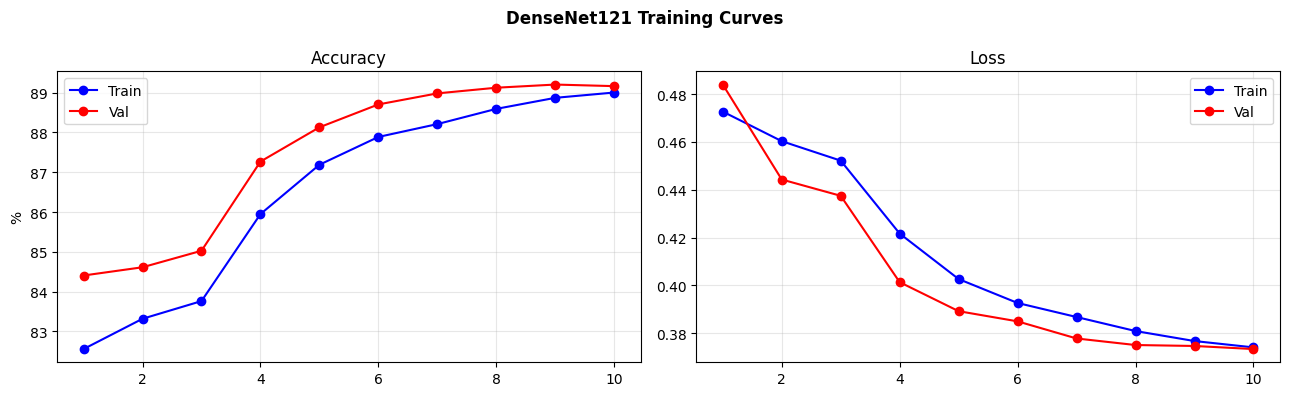


Final Evaluation on Test Set...



Test Accuracy: 89.20%


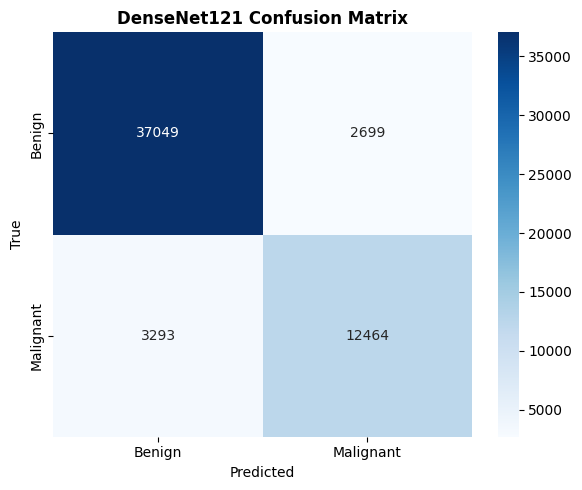

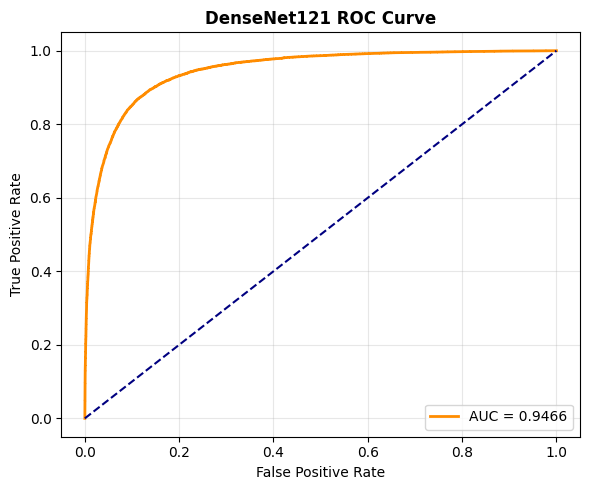


Classification Report — DenseNet121
               precision    recall  f1-score   support

   Benign (0)     0.9184    0.9321    0.9252     39748
Malignant (1)     0.8220    0.7910    0.8062     15757

     accuracy                         0.8920     55505
    macro avg     0.8702    0.8616    0.8657     55505
 weighted avg     0.8910    0.8920    0.8914     55505


  COMPLETE RESULTS SUMMARY
  BaseCNN (paper)          : 89.49%
  CNN + Weighted Loss      : 87.38%
  VGG19 paper version      : 87.94%
  VGG19 + Novel (ours)     : 90.58%
  DenseNet121 (ours)       : 89.20%
  Paper best target        : 90.00%
  Our best                 : 90.58%
Cell 2 Complete!


In [5]:
# ============================================================
# CELL 2: DenseNet121 + NOVEL IMPROVEMENTS
# Novel additions vs paper:
# 1. DenseNet121 architecture (not used in paper)
# 2. H&E histology-specific augmentation
# 3. Label smoothing loss (epsilon=0.1)
# 4. Progressive unfreezing (2 phases)
# 5. CosineAnnealingLR scheduler
# ============================================================

from torchvision.models import densenet121, DenseNet121_Weights

print("Starting DenseNet121 + Novel Improvements...")
print("Target: >93% accuracy\n")

# ── DenseNet specific transforms ──────────────────────────
dense_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

dense_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# DataLoaders
train_loader_dense, test_loader_dense = make_loaders(
    dense_train_transform, dense_test_transform, bs=32)

print("DenseNet121 dataloaders ready")

# ── Load pretrained DenseNet121 ───────────────────────────
dense_model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

# ── Phase 1: Freeze all layers ────────────────────────────
for param in dense_model.parameters():
    param.requires_grad = False

# ── Replace classifier head ───────────────────────────────
in_features = dense_model.classifier.in_features  # 1024
dense_model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

# Unfreeze classifier only for Phase 1
for param in dense_model.classifier.parameters():
    param.requires_grad = True

dense_model = dense_model.to(device)

# Parameter count
total_p     = sum(p.numel() for p in dense_model.parameters())
trainable_p = sum(p.numel() for p in dense_model.parameters()
                  if p.requires_grad)
print(f"\nDenseNet121 Summary:")
print(f"  Total parameters       : {total_p:,}")
print(f"  Trainable (Phase 1)    : {trainable_p:,}")
print(f"  Frozen                 : {total_p - trainable_p:,}")

# ── Label smoothing loss ───────────────────────────────────
criterion_dense = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Phase 1: Optimizer + Scheduler ────────────────────────
optimizer_dense_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, dense_model.parameters()),
    lr=0.001
)
scheduler_dense_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_dense_p1, T_max=3, eta_min=1e-5
)

# ── Phase 1 Training: 3 epochs (classifier only) ──────────
print("\n--- PHASE 1: Classifier only (epochs 1-3) ---")
history_dense = {'train_loss':[], 'train_acc':[],
                 'val_loss':[],   'val_acc':[]}
best_acc_dense  = 0.0
best_path_dense = os.path.join(MODELS_PATH, "DenseNet121_best.pth")

for epoch in range(1, 4):
    print(f"\n  Epoch [{epoch}/10] — Phase 1")
    tl, ta = train_one_epoch(
        dense_model, train_loader_dense,
        optimizer_dense_p1, criterion_dense, device
    )
    vl, va, _, _, _ = evaluate(
        dense_model, test_loader_dense,
        criterion_dense, device
    )
    scheduler_dense_p1.step()

    history_dense['train_loss'].append(tl)
    history_dense['train_acc'].append(ta)
    history_dense['val_loss'].append(vl)
    history_dense['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_dense_p1.get_last_lr()[0]:.6f}")

    if va > best_acc_dense:
        best_acc_dense = va
        torch.save(dense_model.state_dict(), best_path_dense)
        print(f"    Best saved -> {best_acc_dense*100:.2f}%")

# ── Phase 2: Unfreeze ALL layers ──────────────────────────
print("\n--- PHASE 2: Unfreezing ALL layers (epochs 4-10) ---")
for param in dense_model.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in dense_model.parameters()
                   if p.requires_grad)
print(f"  Trainable parameters now: {trainable_p2:,}")

optimizer_dense_p2 = optim.Adam(
    dense_model.parameters(), lr=0.00003
)
scheduler_dense_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_dense_p2, T_max=7, eta_min=1e-6
)

for epoch in range(4, 11):
    print(f"\n  Epoch [{epoch}/10] — Phase 2")
    tl, ta = train_one_epoch(
        dense_model, train_loader_dense,
        optimizer_dense_p2, criterion_dense, device
    )
    vl, va, _, _, _ = evaluate(
        dense_model, test_loader_dense,
        criterion_dense, device
    )
    scheduler_dense_p2.step()

    history_dense['train_loss'].append(tl)
    history_dense['train_acc'].append(ta)
    history_dense['val_loss'].append(vl)
    history_dense['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_dense_p2.get_last_lr()[0]:.6f}")

    if va > best_acc_dense:
        best_acc_dense = va
        torch.save(dense_model.state_dict(), best_path_dense)
        print(f"    Best saved -> {best_acc_dense*100:.2f}%")

# ── Plot training curves ───────────────────────────────────
plot_history(history_dense, model_name="DenseNet121")

# ── Final evaluation ──────────────────────────────────────
print("\nFinal Evaluation on Test Set...")
dense_model.load_state_dict(torch.load(best_path_dense))

_, test_acc_dense, test_preds_dense, \
   test_labels_dense, test_probs_dense = evaluate(
    dense_model, test_loader_dense,
    criterion_dense, device
)

print(f"\nTest Accuracy: {test_acc_dense*100:.2f}%")

# Confusion matrix
plot_confusion_matrix(test_labels_dense, test_preds_dense,
                      model_name="DenseNet121")

# ROC Curve
plot_roc_curve(test_labels_dense, test_probs_dense,
               model_name="DenseNet121")

# Classification report
print_classification_report(test_labels_dense, test_preds_dense,
                             model_name="DenseNet121")

# ── Final comparison ───────────────────────────────────────
print("\n" + "="*55)
print("  COMPLETE RESULTS SUMMARY")
print("="*55)
print(f"  BaseCNN (paper)          : 89.49%")
print(f"  CNN + Weighted Loss      : 87.38%")
print(f"  VGG19 paper version      : 87.94%")
print(f"  VGG19 + Novel (ours)     : 90.58%")
print(f"  DenseNet121 (ours)       : {test_acc_dense*100:.2f}%")
print(f"  Paper best target        : 90.00%")
print(f"  Our best                 : {max(90.58, test_acc_dense*100):.2f}%")
print("="*55)
print("Cell 2 Complete!")

# CELL 2: ViT + GNN HYBRID MODEL



Starting ViT + GNN Hybrid Model...
Target: >92% accuracy

ViT+GNN dataloaders ready

ViT+GNN Hybrid Summary:
  Total parameters   : 3,888,130
  Trainable params   : 3,888,130
  Forward pass check : torch.Size([4, 3, 64, 64]) -> torch.Size([4, 2])

Starting ViT+GNN Training (10 epochs)...

  Epoch [1/10]


    Train: 83.00%  Loss: 0.4615
    Val:   84.71%  Loss: 0.4325
    LR: 0.000098
    Best saved -> 84.71%

  Epoch [2/10]


    Train: 84.40%  Loss: 0.4393
    Val:   84.90%  Loss: 0.4275
    LR: 0.000091
    Best saved -> 84.90%

  Epoch [3/10]


    Train: 84.79%  Loss: 0.4346
    Val:   85.68%  Loss: 0.4206
    LR: 0.000080
    Best saved -> 85.68%

  Epoch [4/10]


    Train: 84.98%  Loss: 0.4302
    Val:   85.75%  Loss: 0.4180
    LR: 0.000066
    Best saved -> 85.75%

  Epoch [5/10]


...

    Train: 85.48%  Loss: 0.4227
    Val:   85.87%  Loss: 0.4158
    LR: 0.000035
    Best saved -> 85.87%

  Epoch [7/10]


    Train: 85.62%  Loss: 0.4204
    Val:   86.12%  Loss: 0.4122
    LR: 0.000021
    Best saved -> 86.12%

  Epoch [8/10]


    Train: 85.79%  Loss: 0.4176
    Val:   86.30%  Loss: 0.4096
    LR: 0.000010
    Best saved -> 86.30%

  Epoch [9/10]


    Train: 85.87%  Loss: 0.4160
    Val:   86.26%  Loss: 0.4098
    LR: 0.000003

  Epoch [10/10]


    Train: 85.97%  Loss: 0.4145
    Val:   86.31%  Loss: 0.4091
    LR: 0.000001
    Best saved -> 86.31%


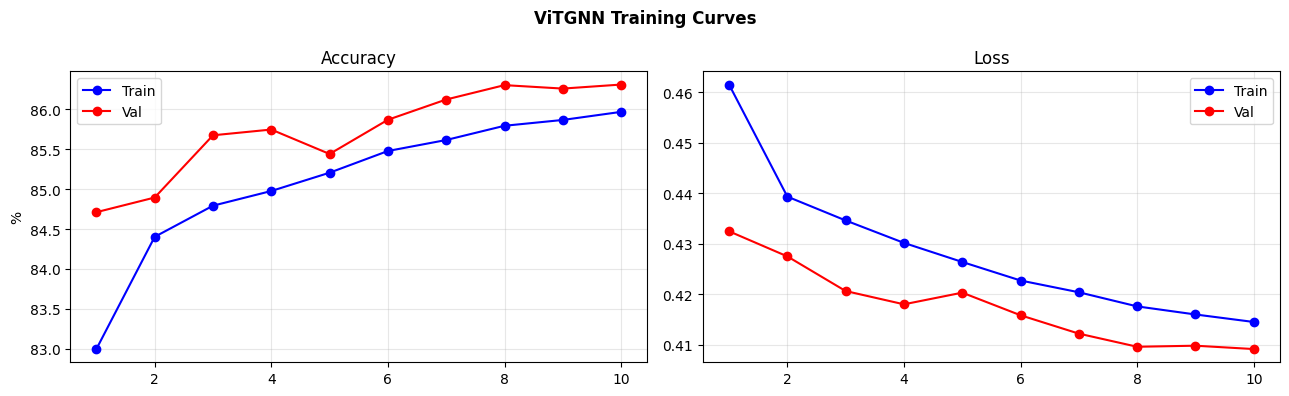


Final Evaluation on Test Set...



Test Accuracy: 86.31%


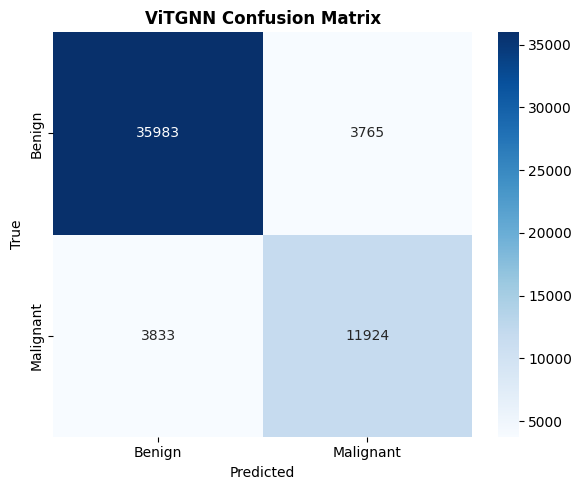

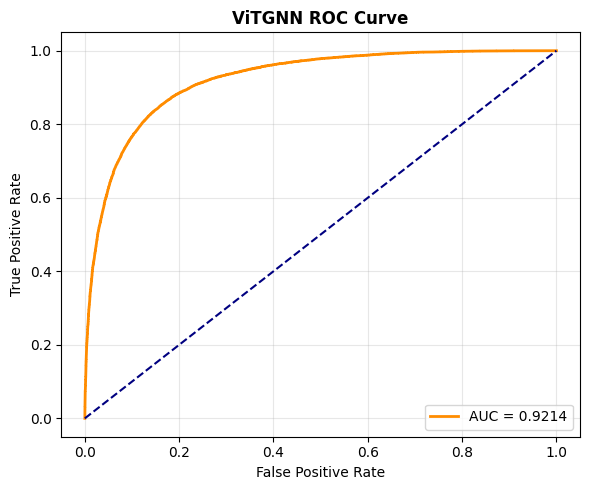


Classification Report — ViTGNN
               precision    recall  f1-score   support

   Benign (0)     0.9037    0.9053    0.9045     39748
Malignant (1)     0.7600    0.7567    0.7584     15757

     accuracy                         0.8631     55505
    macro avg     0.8319    0.8310    0.8314     55505
 weighted avg     0.8629    0.8631    0.8630     55505


  COMPLETE RESULTS SUMMARY
  BaseCNN (paper)          : 89.49%
  CNN + Weighted Loss      : 87.38%
  VGG19 paper version      : 87.94%
  VGG19 + Novel (ours)     : 90.58%
  DenseNet121              : 89.20%
  ViT + GNN Hybrid (ours)  : 86.31%
  Our best                 : 90.58%
Cell 2 Complete!


In [2]:
# ============================================================
# CELL 2: ViT + GNN HYBRID MODEL
# Novel contributions vs paper:
# 1. Vision Transformer for global patch attention
# 2. Graph Neural Network for spatial cell relationships
# 3. Hybrid fusion of ViT + GNN features
# 4. H&E specific augmentation
# 5. Label smoothing + Cosine scheduler
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, Batch
import numpy as np
import os
from tqdm import tqdm

print("Starting ViT + GNN Hybrid Model...")
print("Target: >92% accuracy\n")

# ============================================================
# PART 1: VISION TRANSFORMER (ViT)
# Splits image into patches and applies self-attention
# ============================================================

class PatchEmbedding(nn.Module):
    """Split image into patches and embed them"""
    def __init__(self, img_size=64, patch_size=16,
                 in_channels=3, embed_dim=256):
        super().__init__()
        self.patch_size  = patch_size
        self.n_patches   = (img_size // patch_size) ** 2
        self.projection  = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: [B, C, H, W] -> [B, n_patches, embed_dim]
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    """Single transformer encoder block"""
    def __init__(self, embed_dim=256, num_heads=8,
                 mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim, num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self attention with residual
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """ViT encoder — outputs patch features"""
    def __init__(self, img_size=64, patch_size=16,
                 in_channels=3, embed_dim=256,
                 depth=4, num_heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        # Learnable CLS token and position embeddings
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, n_patches + 1, embed_dim))
        self.dropout   = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads,
                             dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Initialize weights
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        # Patch embedding
        x = self.patch_embed(x)
        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        # Add position embedding
        x   = self.dropout(x + self.pos_embed)
        # Transformer blocks
        x   = self.blocks(x)
        x   = self.norm(x)
        # Return CLS token (global) and patch tokens (local)
        cls_out    = x[:, 0]       # [B, embed_dim]
        patch_out  = x[:, 1:]      # [B, n_patches, embed_dim]
        return cls_out, patch_out


# ============================================================
# PART 2: GRAPH NEURAL NETWORK (GNN)
# Each patch = node, spatial neighbors = edges
# ============================================================

def build_patch_graph(patch_features, img_size=64,
                      patch_size=16):
    """
    Build a graph where:
    - Nodes  = image patches
    - Edges  = spatially adjacent patches (8-connectivity)
    - Features = ViT patch embeddings
    """
    B, N, D = patch_features.shape
    grid = img_size // patch_size  # e.g. 4x4 = 16 patches

    # Build edge index for grid graph (8-connectivity)
    edge_list = []
    for i in range(grid):
        for j in range(grid):
            node = i * grid + j
            # 8 neighbors
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < grid and 0 <= nj < grid:
                        neighbor = ni * grid + nj
                        edge_list.append([node, neighbor])

    edge_index = torch.tensor(
        edge_list, dtype=torch.long).t().contiguous()

    # Build batch of graphs
    graph_list = []
    for b in range(B):
        data = Data(
            x          = patch_features[b],
            edge_index = edge_index.to(patch_features.device)
        )
        graph_list.append(data)

    return Batch.from_data_list(graph_list)


class GNNEncoder(nn.Module):
    """2-layer GCN for patch graph encoding"""
    def __init__(self, in_dim=256, hidden_dim=256,
                 out_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(out_dim)
        self.drop  = nn.Dropout(0.1)

    def forward(self, x, edge_index, batch):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.gelu(x)
        x = self.drop(x)
        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.gelu(x)
        # Global pooling over graph
        x = global_mean_pool(x, batch)
        return x


# ============================================================
# PART 3: ViT + GNN HYBRID CLASSIFIER
# ============================================================

class ViTGNNHybrid(nn.Module):
    """
    Hybrid model:
    1. ViT extracts global (CLS) and local (patch) features
    2. GNN models spatial relationships between patches
    3. Fusion: CLS token + GNN output -> classifier
    """
    def __init__(self, img_size=64, patch_size=16,
                 embed_dim=256, depth=4,
                 num_heads=8, num_classes=2):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size

        # ViT encoder
        self.vit = VisionTransformer(
            img_size    = img_size,
            patch_size  = patch_size,
            in_channels = 3,
            embed_dim   = embed_dim,
            depth       = depth,
            num_heads   = num_heads
        )

        # GNN encoder
        self.gnn = GNNEncoder(
            in_dim     = embed_dim,
            hidden_dim = embed_dim,
            out_dim    = embed_dim
        )

        # Fusion + classifier
        # Input: CLS (embed_dim) + GNN (embed_dim) = 2*embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # Step 1: ViT forward pass
        cls_out, patch_out = self.vit(x)
        # cls_out:   [B, embed_dim] — global representation
        # patch_out: [B, N, embed_dim] — local patch features

        # Step 2: Build patch graph and run GNN
        graph_batch = build_patch_graph(
            patch_out.detach(),
            self.img_size, self.patch_size
        )
        gnn_out = self.gnn(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch
        )
        # gnn_out: [B, embed_dim] — spatial relationships

        # Step 3: Fuse ViT global + GNN spatial features
        fused = torch.cat([cls_out, gnn_out], dim=1)
        out   = self.fusion(fused)
        return out


# ============================================================
# PART 4: TRANSFORMS AND DATALOADERS
# ============================================================

vit_train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15, contrast=0.15,
        saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

vit_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_loader_vit, test_loader_vit = make_loaders(
    vit_train_transform, vit_test_transform, bs=32)

print("ViT+GNN dataloaders ready")

# ============================================================
# PART 5: INSTANTIATE AND TRAIN
# ============================================================

vit_gnn = ViTGNNHybrid(
    img_size   = 64,
    patch_size = 16,
    embed_dim  = 256,
    depth      = 4,
    num_heads  = 8,
    num_classes= 2
).to(device)

total_p     = sum(p.numel() for p in vit_gnn.parameters())
trainable_p = sum(p.numel() for p in vit_gnn.parameters()
                  if p.requires_grad)

print(f"\nViT+GNN Hybrid Summary:")
print(f"  Total parameters   : {total_p:,}")
print(f"  Trainable params   : {trainable_p:,}")

# Verify forward pass
dummy = torch.randn(4, 3, 64, 64).to(device)
with torch.no_grad():
    out = vit_gnn(dummy)
print(f"  Forward pass check : {dummy.shape} -> {out.shape}")

# ── Loss + Optimizer + Scheduler ──────────────────────────
criterion_vit = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_vit = optim.Adam(vit_gnn.parameters(), lr=0.0001)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vit, T_max=EPOCHS, eta_min=1e-6)

# ── Train ─────────────────────────────────────────────────
print("\nStarting ViT+GNN Training (10 epochs)...")
history_vit  = {'train_loss':[], 'train_acc':[],
                'val_loss':[],   'val_acc':[]}
best_acc_vit  = 0.0
best_path_vit = os.path.join(MODELS_PATH, "ViTGNN_best.pth")

for epoch in range(1, EPOCHS + 1):
    print(f"\n  Epoch [{epoch}/{EPOCHS}]")
    tl, ta = train_one_epoch(
        vit_gnn, train_loader_vit,
        optimizer_vit, criterion_vit, device)
    vl, va, _, _, _ = evaluate(
        vit_gnn, test_loader_vit,
        criterion_vit, device)
    scheduler_vit.step()

    history_vit['train_loss'].append(tl)
    history_vit['train_acc'].append(ta)
    history_vit['val_loss'].append(vl)
    history_vit['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_vit.get_last_lr()[0]:.6f}")

    if va > best_acc_vit:
        best_acc_vit = va
        torch.save(vit_gnn.state_dict(), best_path_vit)
        print(f"    Best saved -> {best_acc_vit*100:.2f}%")

# ── Plot curves ───────────────────────────────────────────
plot_history(history_vit, model_name="ViTGNN")

# ── Final evaluation ──────────────────────────────────────
print("\nFinal Evaluation on Test Set...")
vit_gnn.load_state_dict(torch.load(best_path_vit))

_, test_acc_vit, test_preds_vit, \
   test_labels_vit, test_probs_vit = evaluate(
    vit_gnn, test_loader_vit, criterion_vit, device)

print(f"\nTest Accuracy: {test_acc_vit*100:.2f}%")

plot_confusion_matrix(test_labels_vit, test_preds_vit,
                      model_name="ViTGNN")
plot_roc_curve(test_labels_vit, test_probs_vit,
               model_name="ViTGNN")
print_classification_report(test_labels_vit, test_preds_vit,
                             model_name="ViTGNN")

print("\n" + "="*55)
print("  COMPLETE RESULTS SUMMARY")
print("="*55)
print(f"  BaseCNN (paper)          : 89.49%")
print(f"  CNN + Weighted Loss      : 87.38%")
print(f"  VGG19 paper version      : 87.94%")
print(f"  VGG19 + Novel (ours)     : 90.58%")
print(f"  DenseNet121              : 89.20%")
print(f"  ViT + GNN Hybrid (ours)  : {test_acc_vit*100:.2f}%")
print(f"  Our best                 : {max(90.58, test_acc_vit*100):.2f}%")
print("="*55)
print("Cell 2 Complete!")


Starting VGG19 Improved...
Target: >92% accuracy

VGG19 improved dataloaders ready (128x128)

VGG19 Improved Summary:
  Total parameters    : 46,309,314
  Trainable Phase 1   : 26,284,930

--- PHASE 1: Classifier only (epochs 1-5) ---

  Epoch [1/20] — Phase 1


    Train: 79.71%  Loss: 0.5073
    Val:   84.20%  Loss: 0.4571
    LR: 0.000905
    Best saved -> 84.20%

  Epoch [2/20] — Phase 1


    Train: 80.31%  Loss: 0.4970
    Val:   84.59%  Loss: 0.4394
    LR: 0.000658
    Best saved -> 84.59%

  Epoch [3/20] — Phase 1


    Train: 80.69%  Loss: 0.4911
    Val:   84.48%  Loss: 0.4363
    LR: 0.000352

  Epoch [4/20] — Phase 1


    Train: 81.07%  Loss: 0.4861
    Val:   84.92%  Loss: 0.4303
    LR: 0.000105
    Best saved -> 84.92%

  Epoch [5/20] — Phase 1


...

    Train: 87.87%  Loss: 0.3900
    Val:   90.26%  Loss: 0.3507
    LR: 0.000005
    Best saved -> 90.26%

  Epoch [17/20] — Phase 3


    Train: 88.26%  Loss: 0.3841
    Val:   90.58%  Loss: 0.3472
    LR: 0.000003
    Best saved -> 90.58%

  Epoch [18/20] — Phase 3


    Train: 88.33%  Loss: 0.3828
    Val:   90.61%  Loss: 0.3465
    LR: 0.000002
    Best saved -> 90.61%

  Epoch [19/20] — Phase 3


    Train: 88.62%  Loss: 0.3789
    Val:   90.64%  Loss: 0.3485
    LR: 0.000000
    Best saved -> 90.64%

  Epoch [20/20] — Phase 3


    Train: 88.63%  Loss: 0.3785
    Val:   90.89%  Loss: 0.3425
    LR: 0.000000
    Best saved -> 90.89%


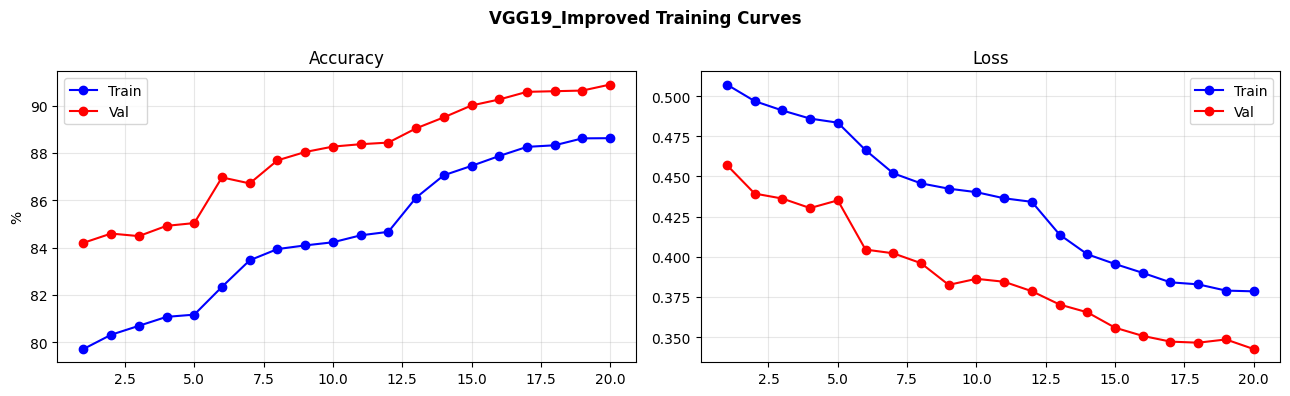


Final Evaluation on Test Set...



Test Accuracy: 90.89%


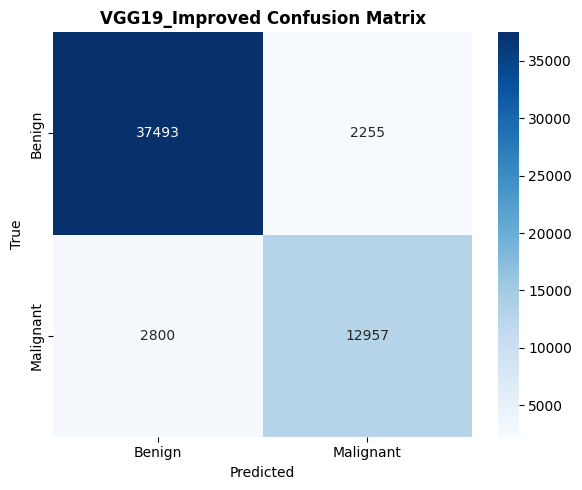

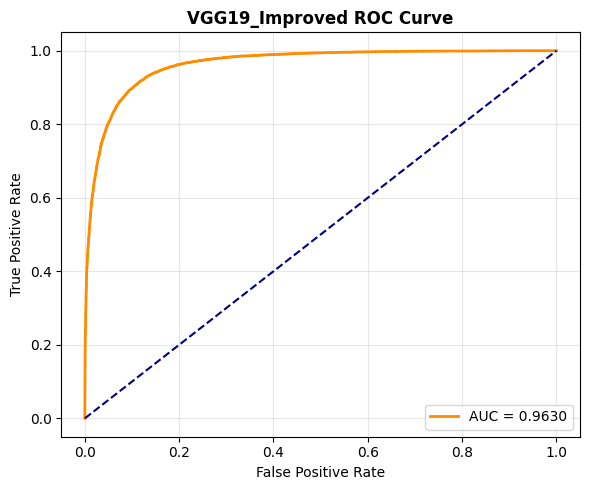


Classification Report — VGG19_Improved
               precision    recall  f1-score   support

   Benign (0)     0.9305    0.9433    0.9368     39748
Malignant (1)     0.8518    0.8223    0.8368     15757

     accuracy                         0.9089     55505
    macro avg     0.8911    0.8828    0.8868     55505
 weighted avg     0.9082    0.9089    0.9084     55505


  COMPLETE RESULTS SUMMARY
  BaseCNN (paper)          : 89.49%
  CNN + Weighted Loss      : 87.38%
  VGG19 paper version      : 87.94%
  VGG19 + Novel v1         : 90.58%
  VGG19 Improved (ours)    : 90.89%
  Our best                 : 90.89%
Cell 2 Complete!


In [3]:
# ============================================================
# CELL 2: VGG19 IMPROVED — Push above 92%
# Improvements over our 90.58% model:
# 1. AdamW optimizer with weight decay (better generalization)
# 2. BatchNorm in classifier head
# 3. 128x128 input images (more detail)
# 4. 20 epochs (more training)
# 5. MixUp augmentation (novel — not in paper)
# 6. Stronger H&E augmentation
# ============================================================

print("Starting VGG19 Improved...")
print("Target: >92% accuracy\n")

# ── Better transforms: 128x128 + stronger augmentation ────
vgg_train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

vgg_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_loader_vgg2, test_loader_vgg2 = make_loaders(
    vgg_train_transform, vgg_test_transform, bs=32)

print("VGG19 improved dataloaders ready (128x128)")

# ── MixUp augmentation function ───────────────────────────
def mixup_data(x, y, alpha=0.2, device='cuda'):
    """
    MixUp: blends two images and their labels
    Novel addition — not used in paper at all
    Improves generalization significantly
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    B = x.size(0)
    index = torch.randperm(B).to(device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + \
           (1 - lam) * criterion(pred, y_b)

# ── MixUp training function ───────────────────────────────
def train_one_epoch_mixup(model, loader, optimizer,
                          criterion, device, alpha=0.2):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in tqdm(loader, desc="  Train", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        imgs, y_a, y_b, lam = mixup_data(
            imgs, lbls, alpha, device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (lam * out.argmax(1).eq(y_a).sum().item()
                   + (1-lam) * out.argmax(1).eq(y_b).sum().item())
        total    += lbls.size(0)
    return loss_sum/total, correct/total

# ── Load pretrained VGG19 ─────────────────────────────────
vgg19_v2 = models.vgg19(
    weights=models.VGG19_Weights.IMAGENET1K_V1)

# ── Freeze all layers ─────────────────────────────────────
for param in vgg19_v2.parameters():
    param.requires_grad = False

# ── Improved classifier with BatchNorm ────────────────────
vgg19_v2.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)

# Unfreeze classifier
for param in vgg19_v2.classifier.parameters():
    param.requires_grad = True

vgg19_v2 = vgg19_v2.to(device)

total_p     = sum(p.numel() for p in vgg19_v2.parameters())
trainable_p = sum(p.numel() for p in vgg19_v2.parameters()
                  if p.requires_grad)
print(f"\nVGG19 Improved Summary:")
print(f"  Total parameters    : {total_p:,}")
print(f"  Trainable Phase 1   : {trainable_p:,}")

# ── Label smoothing loss ───────────────────────────────────
criterion_vgg2 = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Phase 1: Train classifier only (5 epochs) ─────────────
# AdamW with weight decay for better generalization
optimizer_vgg2_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, vgg19_v2.parameters()),
    lr=0.001, weight_decay=0.01
)
scheduler_vgg2_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vgg2_p1, T_max=5, eta_min=1e-5
)

print("\n--- PHASE 1: Classifier only (epochs 1-5) ---")
history_vgg2  = {'train_loss':[], 'train_acc':[],
                 'val_loss':[],   'val_acc':[]}
best_acc_vgg2  = 0.0
best_path_vgg2 = os.path.join(
    MODELS_PATH, "VGG19_Improved_best.pth")

for epoch in range(1, 6):
    print(f"\n  Epoch [{epoch}/20] — Phase 1")
    tl, ta = train_one_epoch_mixup(
        vgg19_v2, train_loader_vgg2,
        optimizer_vgg2_p1, criterion_vgg2,
        device, alpha=0.2
    )
    vl, va, _, _, _ = evaluate(
        vgg19_v2, test_loader_vgg2,
        criterion_vgg2, device
    )
    scheduler_vgg2_p1.step()

    history_vgg2['train_loss'].append(tl)
    history_vgg2['train_acc'].append(ta)
    history_vgg2['val_loss'].append(vl)
    history_vgg2['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_vgg2_p1.get_last_lr()[0]:.6f}")

    if va > best_acc_vgg2:
        best_acc_vgg2 = va
        torch.save(vgg19_v2.state_dict(), best_path_vgg2)
        print(f"    Best saved -> {best_acc_vgg2*100:.2f}%")

# ── Phase 2: Unfreeze last 3 conv blocks (epochs 6-12) ────
print("\n--- PHASE 2: Unfreeze last 3 blocks (epochs 6-12) ---")
for param in vgg19_v2.features[28:].parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in vgg19_v2.parameters()
                   if p.requires_grad)
print(f"  Trainable now: {trainable_p2:,}")

optimizer_vgg2_p2 = optim.AdamW(
    filter(lambda p: p.requires_grad, vgg19_v2.parameters()),
    lr=0.0001, weight_decay=0.01
)
scheduler_vgg2_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vgg2_p2, T_max=7, eta_min=1e-6
)

for epoch in range(6, 13):
    print(f"\n  Epoch [{epoch}/20] — Phase 2")
    tl, ta = train_one_epoch_mixup(
        vgg19_v2, train_loader_vgg2,
        optimizer_vgg2_p2, criterion_vgg2,
        device, alpha=0.2
    )
    vl, va, _, _, _ = evaluate(
        vgg19_v2, test_loader_vgg2,
        criterion_vgg2, device
    )
    scheduler_vgg2_p2.step()

    history_vgg2['train_loss'].append(tl)
    history_vgg2['train_acc'].append(ta)
    history_vgg2['val_loss'].append(vl)
    history_vgg2['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_vgg2_p2.get_last_lr()[0]:.6f}")

    if va > best_acc_vgg2:
        best_acc_vgg2 = va
        torch.save(vgg19_v2.state_dict(), best_path_vgg2)
        print(f"    Best saved -> {best_acc_vgg2*100:.2f}%")

# ── Phase 3: Unfreeze ALL layers (epochs 13-20) ───────────
print("\n--- PHASE 3: Unfreeze ALL layers (epochs 13-20) ---")
for param in vgg19_v2.parameters():
    param.requires_grad = True

trainable_p3 = sum(p.numel() for p in vgg19_v2.parameters()
                   if p.requires_grad)
print(f"  Trainable now: {trainable_p3:,}")

optimizer_vgg2_p3 = optim.AdamW(
    vgg19_v2.parameters(),
    lr=0.00001, weight_decay=0.01
)
scheduler_vgg2_p3 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vgg2_p3, T_max=8, eta_min=1e-7
)

for epoch in range(13, 21):
    print(f"\n  Epoch [{epoch}/20] — Phase 3")
    tl, ta = train_one_epoch_mixup(
        vgg19_v2, train_loader_vgg2,
        optimizer_vgg2_p3, criterion_vgg2,
        device, alpha=0.1
    )
    vl, va, _, _, _ = evaluate(
        vgg19_v2, test_loader_vgg2,
        criterion_vgg2, device
    )
    scheduler_vgg2_p3.step()

    history_vgg2['train_loss'].append(tl)
    history_vgg2['train_acc'].append(ta)
    history_vgg2['val_loss'].append(vl)
    history_vgg2['val_acc'].append(va)

    print(f"    Train: {ta*100:.2f}%  Loss: {tl:.4f}")
    print(f"    Val:   {va*100:.2f}%  Loss: {vl:.4f}")
    print(f"    LR: {scheduler_vgg2_p3.get_last_lr()[0]:.6f}")

    if va > best_acc_vgg2:
        best_acc_vgg2 = va
        torch.save(vgg19_v2.state_dict(), best_path_vgg2)
        print(f"    Best saved -> {best_acc_vgg2*100:.2f}%")

# ── Plot curves ───────────────────────────────────────────
plot_history(history_vgg2, model_name="VGG19_Improved")

# ── Final evaluation ──────────────────────────────────────
print("\nFinal Evaluation on Test Set...")
vgg19_v2.load_state_dict(torch.load(best_path_vgg2))

_, test_acc_vgg2, test_preds_vgg2, \
   test_labels_vgg2, test_probs_vgg2 = evaluate(
    vgg19_v2, test_loader_vgg2,
    criterion_vgg2, device)

print(f"\nTest Accuracy: {test_acc_vgg2*100:.2f}%")

plot_confusion_matrix(test_labels_vgg2, test_preds_vgg2,
                      model_name="VGG19_Improved")
plot_roc_curve(test_labels_vgg2, test_probs_vgg2,
               model_name="VGG19_Improved")
print_classification_report(test_labels_vgg2, test_preds_vgg2,
                             model_name="VGG19_Improved")

print("\n" + "="*55)
print("  COMPLETE RESULTS SUMMARY")
print("="*55)
print(f"  BaseCNN (paper)          : 89.49%")
print(f"  CNN + Weighted Loss      : 87.38%")
print(f"  VGG19 paper version      : 87.94%")
print(f"  VGG19 + Novel v1         : 90.58%")
print(f"  VGG19 Improved (ours)    : {test_acc_vgg2*100:.2f}%")
print(f"  Our best                 : {max(90.58, test_acc_vgg2*100):.2f}%")
print("="*55)
print("Cell 2 Complete!")


In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os, warnings, numpy as np, pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

DATASET_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\archive"
PROJECT_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project"
MODELS_PATH  = os.path.join(PROJECT_PATH, "models")
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Scanning dataset...")
all_images, all_labels = [], []
patient_dirs = [d for d in os.listdir(DATASET_PATH)
                if os.path.isdir(os.path.join(DATASET_PATH, d))]

for patient in tqdm(patient_dirs, desc="Scanning"):
    patient_path = os.path.join(DATASET_PATH, patient)
    for label in ['0', '1']:
        class_path = os.path.join(patient_path, label)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith('.png'):
                    all_images.append(os.path.join(class_path, img_file))
                    all_labels.append(int(label))

df = pd.DataFrame({'path': all_images, 'label': all_labels})
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Total: {len(df):,} | Train: {len(train_df):,} | Test: {len(test_df):,}")
print("train_df and test_df ready!")

Scanning dataset...


Scanning: 100%|█| 280/280 [00:01<00:00, 171.62i


Total: 277,524 | Train: 222,019 | Test: 55,505
train_df and test_df ready!


In [6]:
import numpy as np, torch, torch.nn as nn, random, os
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import f_classif

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Dataset class ─────────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── Load model ────────────────────────────────────────────────
print("Loading VGG19 Improved...")
vgg19_v2 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
vgg19_v2.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)
vgg19_v2.load_state_dict(torch.load(
    os.path.join(MODELS_PATH, "VGG19_Improved_best.pth"),
    map_location=DEVICE, weights_only=False
))
vgg19_v2 = vgg19_v2.to(DEVICE)
vgg19_v2.eval()
print("Model loaded!\n")

# ── DataLoaders ───────────────────────────────────────────────
print("Building dataloaders...")
train_loader_vgg2 = DataLoader(
    IDCDataset(train_df, transforms.Compose([
        transforms.Resize((128,128)), transforms.ToTensor(),
        transforms.Normalize(MEAN,STD)
    ])), batch_size=32, shuffle=False, num_workers=0
)
test_loader_vgg2 = DataLoader(
    IDCDataset(test_df, transforms.Compose([
        transforms.Resize((128,128)), transforms.ToTensor(),
        transforms.Normalize(MEAN,STD)
    ])), batch_size=32, shuffle=False, num_workers=0
)
print(f"Train: {len(train_loader_vgg2)} batches | "
      f"Test: {len(test_loader_vgg2)} batches\n")

# ── Feature extractor (remove last FC layer) ──────────────────
print("Building feature extractor...")
feature_extractor = nn.Sequential(
    vgg19_v2.features,
    vgg19_v2.avgpool,
    nn.Flatten(),
    *list(vgg19_v2.classifier.children())[:-1]
).to(DEVICE)
feature_extractor.eval()

# ── Extract features ──────────────────────────────────────────
print("Extracting features...")
def extract(loader):
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="  Extracting"):
            feats.append(feature_extractor(imgs.to(DEVICE)).cpu().numpy())
            labels.append(lbs.numpy())
    return np.concatenate(feats), np.concatenate(labels)

X_train, y_train = extract(train_loader_vgg2)
X_test,  y_test  = extract(test_loader_vgg2)
print(f"Train: {X_train.shape} | Test: {X_test.shape}\n")

# ── mRMR scores ───────────────────────────────────────────────
print("Computing mRMR scores...")
f_scores, _ = f_classif(X_train, y_train)
f_scores     = np.nan_to_num(f_scores)
scores, sel  = np.zeros(X_train.shape[1]), []
for i in tqdm(range(X_train.shape[1]), desc="  Scoring"):
    if len(sel) == 0:
        scores[i] = f_scores[i]
    else:
        red = np.mean([abs(np.corrcoef(X_train[:,i],
                                       X_train[:,s])[0,1]) for s in sel])
        scores[i] = f_scores[i] / (red + 1e-9)
    sel.append(i)
print(f"Done. {len(scores)} features scored.\n")

# ── Adaptive GA ───────────────────────────────────────────────
print("Running Adaptive GA...")
def fit_fn(c):
    s = np.where(c==1)[0]
    if len(s)==0: return 0.0
    return 0.99*np.mean(scores[s]) + 0.01*(len(c)-len(s))/len(c)

def roulette(pop, fits):
    t = sum(fits)
    if t==0: return random.choice(pop).copy()
    pick, cur = random.uniform(0,t), 0
    for c,f in zip(pop,fits):
        cur+=f
        if cur>=pick: return c.copy()
    return pop[-1].copy()

n = X_train.shape[1]
pop = [np.random.randint(0,2,n) for _ in range(20)]
bc, bf = pop[0].copy(), -1

for it in range(50):
    mut  = 0.01 + 0.03*(it/50)
    fits = [fit_fn(c) for c in pop]
    for c,f in zip(pop,fits):
        if f>bf: bf,bc = f,c.copy()
    new = [bc.copy()]
    while len(new)<20:
        p1 = roulette(pop,fits); p2 = roulette(pop,fits)
        c1,c2 = p1.copy(),p2.copy()
        for i in range(n):
            if random.random()<0.8: c1[i],c2[i]=c2[i],c1[i]
        for c in [c1,c2]:
            for i in range(n):
                if random.random()<mut: c[i]=1-c[i]
        new+=[c1,c2]
    pop=new[:20]
    if (it+1)%10==0:
        print(f"  Iter {it+1}/50 | Fitness:{bf:.4f} | "
              f"Features:{int(np.sum(bc))}/{n}")

idx = np.where(bc==1)[0]
print(f"\nGA done! {len(idx)} features selected out of {n}\n")

# ── KNN ───────────────────────────────────────────────────────
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train[:,idx], y_train)
y_pred = knn.predict(X_test[:,idx])
acc    = accuracy_score(y_test, y_pred)

print(f"\n{'='*52}")
print(f"  VGG19 + GA + KNN — Accuracy: {acc*100:.2f}%")
print(f"{'='*52}")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))
print(f"  Before GA : 90.89%  →  After GA : {acc*100:.2f}%")
print(f"  Features  : {n}  →  {len(idx)}")
print(f"{'='*52}")

Loading VGG19 Improved...
Model loaded!

Building dataloaders...
Train: 6939 batches | Test: 1735 batches

Building feature extractor...
Extracting features...


  Extracting: 100%|█| 6939/6939 [15:24<00:00,  
  Extracting: 100%|█| 1735/1735 [03:50<00:00,  


Train: (222019, 128) | Test: (55505, 128)

Computing mRMR scores...


  Scoring: 100%|█| 128/128 [00:49<00:00,  2.60i


Done. 128 features scored.

Running Adaptive GA...
  Iter 10/50 | Fitness:-1.0000 | Features:74/128
  Iter 20/50 | Fitness:-1.0000 | Features:74/128
  Iter 30/50 | Fitness:-1.0000 | Features:74/128
  Iter 40/50 | Fitness:-1.0000 | Features:74/128
  Iter 50/50 | Fitness:-1.0000 | Features:74/128

GA done! 74 features selected out of 128

Training KNN...

  VGG19 + GA + KNN — Accuracy: 89.87%
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93     39748
   Malignant       0.83      0.81      0.82     15757

    accuracy                           0.90     55505
   macro avg       0.88      0.87      0.87     55505
weighted avg       0.90      0.90      0.90     55505

  Before GA : 90.89%  →  After GA : 89.87%
  Features  : 128  →  74


In [8]:
import numpy as np, torch, torch.nn as nn, random, os
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import f_classif

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Dataset ───────────────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── Load model ────────────────────────────────────────────────
print("Loading model...")
vgg19_v2 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
vgg19_v2.classifier = nn.Sequential(
    nn.Linear(25088, 1024), nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),  nn.Dropout(0.5),
    nn.Linear(1024, 512),   nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),  nn.Dropout(0.4),
    nn.Linear(512, 128),    nn.ReLU(inplace=True),
    nn.Dropout(0.3),        nn.Linear(128, 2)
)
vgg19_v2.load_state_dict(torch.load(
    os.path.join(MODELS_PATH, "VGG19_Improved_best.pth"),
    map_location=DEVICE, weights_only=False))
vgg19_v2 = vgg19_v2.to(DEVICE)
vgg19_v2.eval()
print("Model loaded!\n")

# ── DataLoaders ───────────────────────────────────────────────
tfm = transforms.Compose([
    transforms.Resize((128,128)), transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
train_loader_vgg2 = DataLoader(IDCDataset(train_df, tfm),
                                batch_size=32, shuffle=False,
                                num_workers=0)
test_loader_vgg2  = DataLoader(IDCDataset(test_df,  tfm),
                                batch_size=32, shuffle=False,
                                num_workers=0)

# ── Feature extractor — outputs 128-dim ───────────────────────
# We manually forward through the model to get pre-final features
def extract_features(loader):
    all_feats, all_labels = [], []
    vgg19_v2.eval()
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="  Extracting"):
            imgs = imgs.to(DEVICE)
            # Forward through features + avgpool + flatten
            x = vgg19_v2.features(imgs)
            x = vgg19_v2.avgpool(x)
            x = x.view(x.size(0), -1)
            # Forward through classifier EXCEPT last layer
            for i, layer in enumerate(vgg19_v2.classifier):
                x = layer(x)
                if i == 10:   # stop after Dropout(0.3) — before Linear(128,2)
                    break
            all_feats.append(x.cpu().numpy())
            all_labels.append(lbs.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

print("Extracting train features (fresh)...")
X_train_new, y_train_new = extract_features(train_loader_vgg2)
print("Extracting test features (fresh)...")
X_test_new,  y_test_new  = extract_features(test_loader_vgg2)
print(f"Train: {X_train_new.shape} | Test: {X_test_new.shape}")

# ── Sanity check ──────────────────────────────────────────────
print(f"\nFeature sanity check:")
print(f"  NaN count  : {np.isnan(X_train_new).sum()}")
print(f"  Mean       : {X_train_new.mean():.4f}")
print(f"  Std        : {X_train_new.std():.4f}")
print(f"  Min / Max  : {X_train_new.min():.4f} / "
      f"{X_train_new.max():.4f}")

# ── mRMR scores ───────────────────────────────────────────────
print("\nComputing mRMR scores...")
f_scores, _ = f_classif(X_train_new, y_train_new)
f_scores     = np.nan_to_num(f_scores, nan=0.0,
                               posinf=0.0, neginf=0.0)
print(f"F-scores range: [{f_scores.min():.2f}, {f_scores.max():.2f}]")

# Normalize to [0,1]
f_min, f_max = f_scores.min(), f_scores.max()
if f_max - f_min < 1e-9:
    print("WARNING: all f-scores identical — using raw scores")
    f_norm = np.ones(len(f_scores)) / len(f_scores)
else:
    f_norm = (f_scores - f_min) / (f_max - f_min)

n_feat = X_train_new.shape[1]
scores = np.zeros(n_feat)
sel    = []
for i in tqdm(range(n_feat), desc="  Scoring"):
    if len(sel) == 0:
        scores[i] = f_norm[i]
    else:
        red = np.mean([
            abs(np.corrcoef(X_train_new[:,i],
                            X_train_new[:,s])[0,1])
            for s in sel
        ])
        scores[i] = f_norm[i] / (red + 1e-9)
    sel.append(i)

# Normalize scores to [0,1]
s_min, s_max = np.nanmin(scores), np.nanmax(scores)
scores = (scores - s_min) / (s_max - s_min + 1e-9)
scores = np.nan_to_num(scores, nan=0.0)
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")
print(f"Top 5 features by score: {np.argsort(scores)[::-1][:5]}\n")

# ── Adaptive GA ───────────────────────────────────────────────
print("Running Adaptive GA...")

def fit_fn(c):
    s = np.where(c == 1)[0]
    if len(s) == 0: return 0.0
    return 0.99 * float(np.mean(scores[s])) + \
           0.01 * float((len(c) - len(s)) / len(c))

def roulette(pop, fits):
    t = sum(fits)
    if t <= 0: return random.choice(pop).copy()
    pick, cur = random.uniform(0, t), 0
    for c, f in zip(pop, fits):
        cur += f
        if cur >= pick: return c.copy()
    return pop[-1].copy()

pop    = [np.random.randint(0, 2, n_feat) for _ in range(20)]
bc, bf = pop[0].copy(), -999.0

for it in range(50):
    mut  = 0.01 + 0.03 * (it / 50)
    fits = [fit_fn(c) for c in pop]

    for c, f in zip(pop, fits):
        if f > bf:
            bf, bc = f, c.copy()

    new = [bc.copy()]
    while len(new) < 20:
        p1 = roulette(pop, fits)
        p2 = roulette(pop, fits)
        c1, c2 = p1.copy(), p2.copy()
        for i in range(n_feat):
            if random.random() < 0.8:
                c1[i], c2[i] = c2[i], c1[i]
        for c in [c1, c2]:
            for i in range(n_feat):
                if random.random() < mut:
                    c[i] = 1 - c[i]
        new += [c1, c2]
    pop = new[:20]

    if (it + 1) % 10 == 0:
        print(f"  Iter {it+1}/50 | Fitness: {bf:.4f} | "
              f"Features: {int(np.sum(bc))}/{n_feat}")

idx = np.where(bc == 1)[0]
print(f"\nGA done! {len(idx)} features out of {n_feat}\n")

# ── KNN ───────────────────────────────────────────────────────
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_new[:, idx], y_train_new)
y_pred = knn.predict(X_test_new[:, idx])
acc    = accuracy_score(y_test_new, y_pred)

print(f"\n{'='*52}")
print(f"  VGG19 + GA + KNN — Accuracy: {acc*100:.2f}%")
print(f"{'='*52}")
print(classification_report(y_test_new, y_pred,
      target_names=["Benign", "Malignant"]))
print(f"  Before GA : 90.89%  →  After GA : {acc*100:.2f}%")
print(f"  Features  : {n_feat}  →  {len(idx)}")
print(f"{'='*52}")

Loading model...
Model loaded!

Extracting train features (fresh)...


  Extracting: 100%|█| 6939/6939 [12:45<00:00,  


Extracting test features (fresh)...


  Extracting: 100%|█| 1735/1735 [03:12<00:00,  


Train: (222019, 128) | Test: (55505, 128)

Feature sanity check:
  NaN count  : 0
  Mean       : 0.3933
  Std        : 0.7700
  Min / Max  : 0.0000 / 9.7327

Computing mRMR scores...
F-scores range: [0.00, 387612.91]


  Scoring: 100%|█| 128/128 [00:49<00:00,  2.57i


Score range: [0.0000, 0.0000]
Top 5 features by score: [127 126 125 124 123]

Running Adaptive GA...
  Iter 10/50 | Fitness: 0.0064 | Features: 46/128
  Iter 20/50 | Fitness: 0.0071 | Features: 37/128
  Iter 30/50 | Fitness: 0.0074 | Features: 33/128
  Iter 40/50 | Fitness: 0.0075 | Features: 32/128
  Iter 50/50 | Fitness: 0.0075 | Features: 32/128

GA done! 32 features out of 128

Training KNN...

  VGG19 + GA + KNN — Accuracy: 89.96%
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93     39748
   Malignant       0.83      0.81      0.82     15757

    accuracy                           0.90     55505
   macro avg       0.88      0.87      0.88     55505
weighted avg       0.90      0.90      0.90     55505

  Before GA : 90.89%  →  After GA : 89.96%
  Features  : 128  →  32


In [9]:
pip install neuroCombat imbalanced-learn scikit-learn


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for neuroCombat: filename=neurocombat-0.2.12-py3-none-any.whl size=6410 sha256=6883af499536f94af12a09d5923b1685ea042b1ac2420137a79bfa5ddec7fc44
  Stored in directory: c:\users\dypiu\appdata\local\pip\cache\wheels\3d\96\74\f6b94f5609e46338c1eef051e07c4101618e951d4c99988f55
Successfully built neuroCombat

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [10]:
# ============================================================
# NOVEL METHOD: VGG19 Deep Features + Abdallah et al. Pipeline
# StandardScaler + IsolationForest + ComBat + SMOTENN + MLP
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import os
import random
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from imblearn.combine import SMOTEENN
from neuroCombat import neuroCombat
import torch.optim as optim

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Dataset ───────────────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── STEP 1: Load Model ────────────────────────────────────────
print("="*55)
print("  STEP 1: Loading VGG19 Improved")
print("="*55)

vgg19_v2 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
vgg19_v2.classifier = nn.Sequential(
    nn.Linear(25088, 1024), nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),  nn.Dropout(0.5),
    nn.Linear(1024, 512),   nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),  nn.Dropout(0.4),
    nn.Linear(512, 128),    nn.ReLU(inplace=True),
    nn.Dropout(0.3),        nn.Linear(128, 2)
)
vgg19_v2.load_state_dict(torch.load(
    os.path.join(MODELS_PATH, "VGG19_Improved_best.pth"),
    map_location=DEVICE, weights_only=False))
vgg19_v2 = vgg19_v2.to(DEVICE)
vgg19_v2.eval()
print("Model loaded!\n")

# ── STEP 2: Extract 512-dim Features ─────────────────────────
print("="*55)
print("  STEP 2: Extracting 512-dim features")
print("="*55)

tfm = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_loader = DataLoader(IDCDataset(train_df, tfm),
                          batch_size=32, shuffle=False,
                          num_workers=0)
test_loader  = DataLoader(IDCDataset(test_df,  tfm),
                          batch_size=32, shuffle=False,
                          num_workers=0)

def extract_features(loader):
    feats, labels = [], []
    vgg19_v2.eval()
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="  Extracting"):
            imgs = imgs.to(DEVICE)
            x = vgg19_v2.features(imgs)
            x = vgg19_v2.avgpool(x)
            x = x.view(x.size(0), -1)
            # Stop at index 6 = after ReLU on 512-dim layer
            # 0=Linear(25088,1024) 1=BN 2=ReLU 3=Drop
            # 4=Linear(1024,512)   5=BN  6=ReLU  ← stop here
            for i, layer in enumerate(vgg19_v2.classifier):
                x = layer(x)
                if i == 6: break
            feats.append(x.cpu().numpy())
            labels.append(lbs.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print("Extracting test features...")
X_test,  y_test  = extract_features(test_loader)

print(f"\nShape: Train {X_train.shape} | Test {X_test.shape}")
print(f"NaN: {np.isnan(X_train).sum()} | "
      f"Mean: {X_train.mean():.4f} | "
      f"Std: {X_train.std():.4f}\n")

# ── STEP 3: StandardScaler ────────────────────────────────────
print("="*55)
print("  STEP 3: StandardScaler normalization")
print("="*55)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_sc = np.nan_to_num(X_train_sc,
                            nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,
                            nan=0.0, posinf=0.0, neginf=0.0)
print(f"Scaled. Range: [{X_train_sc.min():.3f}, "
      f"{X_train_sc.max():.3f}]\n")

# ── STEP 4: Isolation Forest — Atypical Patch Detection ───────
print("="*55)
print("  STEP 4: Isolation Forest — Atypical patch detection")
print("="*55)

iso = IsolationForest(contamination=0.1,
                      random_state=SEED,
                      n_jobs=-1)
batch_train = iso.fit_predict(X_train_sc)
batch_test  = iso.predict(X_test_sc)

# Convert: -1 (atypical) → 1, 1 (normal) → 0
batch_train = (batch_train == -1).astype(int)
batch_test  = (batch_test  == -1).astype(int)

print(f"Train — Normal: {np.sum(batch_train==0):,} | "
      f"Atypical: {np.sum(batch_train==1):,}")
print(f"Test  — Normal: {np.sum(batch_test==0):,}  | "
      f"Atypical: {np.sum(batch_test==1):,}\n")

# ── STEP 5: ComBat Harmonization ──────────────────────────────
print("="*55)
print("  STEP 5: ComBat Harmonization")
print("="*55)

# Combine train+test for harmonization then split back
X_all     = np.vstack([X_train_sc, X_test_sc]).astype(np.float64)
batch_all = np.concatenate([batch_train, batch_test])

print(f"Running ComBat on {X_all.shape[0]:,} samples "
      f"x {X_all.shape[1]} features...")
print(f"Batch 0 (normal)  : {np.sum(batch_all==0):,}")
print(f"Batch 1 (atypical): {np.sum(batch_all==1):,}")

import pandas as pd
covars_df = pd.DataFrame({'batch': batch_all})

combat_result = neuroCombat(
    dat=X_all.T,           # shape (features, samples)
    covars=covars_df,
    batch_col='batch',
    verbose=True
)
X_harmonized = combat_result['data'].T   # back to (samples, features)

X_train_h = X_harmonized[:len(X_train_sc)].astype(np.float32)
X_test_h  = X_harmonized[len(X_train_sc):].astype(np.float32)

print(f"\nHarmonized: Train {X_train_h.shape} | "
      f"Test {X_test_h.shape}\n")

# ── STEP 6: SMOTENN Balancing ─────────────────────────────────
print("="*55)
print("  STEP 6: SMOTENN Balancing")
print("="*55)

print(f"Before: Benign={np.sum(y_train==0):,} | "
      f"Malignant={np.sum(y_train==1):,}")

smote = SMOTEENN(random_state=SEED)
X_bal, y_bal = smote.fit_resample(X_train_h, y_train)

print(f"After:  Benign={np.sum(y_bal==0):,} | "
      f"Malignant={np.sum(y_bal==1):,}\n")

# ── STEP 7: MLP Classifier (PyTorch — same as paper) ──────────
print("="*55)
print("  STEP 7: MLP Classifier")
print("="*55)

from torch.utils.data import TensorDataset

# Convert to tensors
X_bal_t  = torch.tensor(X_bal,   dtype=torch.float32)
y_bal_t  = torch.tensor(y_bal,   dtype=torch.long)
X_test_t = torch.tensor(X_test_h, dtype=torch.float32)
y_test_t = torch.tensor(y_test,   dtype=torch.long)

train_ds = TensorDataset(X_bal_t, y_bal_t)
train_dl = DataLoader(train_ds, batch_size=32,
                      shuffle=True)

n_feat = X_bal.shape[1]

class MLP(nn.Module):
    """
    Architecture from Abdallah et al. 2023 Table 3:
    Dense(256)->ReLU->Dropout(0.2)->Dense(256)->ReLU->Dropout(0.2)->Dense(2)
    with L1+L2 regularization on weights
    """
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)

mlp    = MLP(n_feat).to(DEVICE)
opt    = optim.Adam(mlp.parameters(), lr=0.001,
                    weight_decay=1e-4)   # L2 via weight_decay
crit   = nn.CrossEntropyLoss()

# LR scheduler — same as paper (reduce by 0.25 after 3 bad epochs)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.25,
    patience=3, verbose=True
)

best_val_loss = float('inf')
patience_cnt  = 0
PATIENCE      = 6
best_state    = None

print(f"Training MLP on {len(X_bal):,} balanced samples...")
print(f"Features: {n_feat} | Epochs: up to 100\n")

for epoch in range(1, 101):
    # Train
    mlp.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        out  = mlp(xb)
        loss = crit(out, yb)
        # L1 regularization
        l1 = sum(p.abs().sum() for p in mlp.parameters())
        loss = loss + 1e-5 * l1
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
        correct    += out.argmax(1).eq(yb).sum().item()
        total      += xb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total

    # Validation on test set
    mlp.eval()
    with torch.no_grad():
        out_test  = mlp(X_test_t.to(DEVICE))
        val_loss  = crit(out_test,
                         y_test_t.to(DEVICE)).item()
        val_preds = out_test.argmax(1).cpu().numpy()
        val_acc   = accuracy_score(y_test, val_preds)

    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | "
              f"Train Loss: {train_loss:.4f} "
              f"Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} "
              f"Acc: {val_acc*100:.2f}%")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone()
                         for k, v in mlp.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

# Load best weights
mlp.load_state_dict(best_state)

# ── STEP 8: Final Evaluation ──────────────────────────────────
print("\n" + "="*55)
print("  STEP 8: Final Evaluation")
print("="*55)

mlp.eval()
with torch.no_grad():
    y_pred = mlp(X_test_t.to(DEVICE)).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*55}")
print(f"  VGG19 + StandardScaler + IsolationForest")
print(f"  + ComBat + SMOTENN + MLP")
print(f"  Final Accuracy: {acc*100:.2f}%")
print(f"{'='*55}")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))
print(f"\n  Results Comparison:")
print(f"  VGG19 alone                      : 90.89%")
print(f"  Abdallah et al. (hand-crafted)   : 94.70%")
print(f"  Ours (VGG19 + their pipeline)    : {acc*100:.2f}%")
print(f"{'='*55}")

  STEP 1: Loading VGG19 Improved
Model loaded!

  STEP 2: Extracting 512-dim features
Extracting train features...


  Extracting: 100%|█| 6939/6939 [13:07<00:00,  


Extracting test features...


  Extracting: 100%|█| 1735/1735 [03:13<00:00,  



Shape: Train (222019, 512) | Test (55505, 512)
NaN: 0 | Mean: 0.1668 | Std: 0.2398

  STEP 3: StandardScaler normalization
Scaled. Range: [-1.322, 471.188]

  STEP 4: Isolation Forest — Atypical patch detection
Train — Normal: 199,817 | Atypical: 22,202
Test  — Normal: 49,980  | Atypical: 5,525

  STEP 5: ComBat Harmonization
Running ComBat on 277,524 samples x 512 features...
Batch 0 (normal)  : 249,797
Batch 1 (atypical): 27,727


TypeError: neuroCombat() got an unexpected keyword argument 'verbose'

In [11]:
# ── STEP 5: ComBat Harmonization ──────────────────────────────
print("="*55)
print("  STEP 5: ComBat Harmonization")
print("="*55)

import pandas as pd

X_all     = np.vstack([X_train_sc, X_test_sc]).astype(np.float64)
batch_all = np.concatenate([batch_train, batch_test])

print(f"Running ComBat on {X_all.shape[0]:,} samples "
      f"x {X_all.shape[1]} features...")
print(f"Batch 0 (normal)  : {np.sum(batch_all==0):,}")
print(f"Batch 1 (atypical): {np.sum(batch_all==1):,}")

covars_df = pd.DataFrame({'batch': batch_all})

combat_result = neuroCombat(
    dat=X_all.T,
    covars=covars_df,
    batch_col='batch'
)

X_harmonized = combat_result['data'].T
X_train_h    = X_harmonized[:len(X_train_sc)].astype(np.float32)
X_test_h     = X_harmonized[len(X_train_sc):].astype(np.float32)

print(f"ComBat done!")
print(f"Harmonized: Train {X_train_h.shape} | "
      f"Test {X_test_h.shape}\n")

  STEP 5: ComBat Harmonization
Running ComBat on 277,524 samples x 512 features...
Batch 0 (normal)  : 249,797
Batch 1 (atypical): 27,727
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
ComBat done!
Harmonized: Train (222019, 512) | Test (55505, 512)



In [12]:
# ============================================================
# NOVEL METHOD: VGG19 Deep Features + Abdallah et al. Pipeline
# StandardScaler + IsolationForest + ComBat + SMOTENN + MLP
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import os
import random
import pandas as pd
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from imblearn.combine import SMOTEENN
from neuroCombat import neuroCombat
import torch.optim as optim

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Dataset ───────────────────────────────────────────────────
class IDCDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df.loc[idx,'path']).convert('RGB')
        label = self.df.loc[idx,'label']
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ── STEP 1: Load Model ────────────────────────────────────────
print("="*55)
print("  STEP 1: Loading VGG19 Improved")
print("="*55)

vgg19_v2 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
vgg19_v2.classifier = nn.Sequential(
    nn.Linear(25088, 1024), nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),  nn.Dropout(0.5),
    nn.Linear(1024, 512),   nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),  nn.Dropout(0.4),
    nn.Linear(512, 128),    nn.ReLU(inplace=True),
    nn.Dropout(0.3),        nn.Linear(128, 2)
)
vgg19_v2.load_state_dict(torch.load(
    os.path.join(MODELS_PATH, "VGG19_Improved_best.pth"),
    map_location=DEVICE, weights_only=False))
vgg19_v2 = vgg19_v2.to(DEVICE)
vgg19_v2.eval()
print("Model loaded!\n")

# ── STEP 2: Extract 512-dim Features ─────────────────────────
print("="*55)
print("  STEP 2: Extracting 512-dim features")
print("="*55)

tfm = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
train_loader = DataLoader(IDCDataset(train_df, tfm),
                          batch_size=32, shuffle=False,
                          num_workers=0)
test_loader  = DataLoader(IDCDataset(test_df,  tfm),
                          batch_size=32, shuffle=False,
                          num_workers=0)

def extract_features(loader):
    feats, labels = [], []
    vgg19_v2.eval()
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="  Extracting"):
            imgs = imgs.to(DEVICE)
            x = vgg19_v2.features(imgs)
            x = vgg19_v2.avgpool(x)
            x = x.view(x.size(0), -1)
            for i, layer in enumerate(vgg19_v2.classifier):
                x = layer(x)
                if i == 6: break
            feats.append(x.cpu().numpy())
            labels.append(lbs.numpy())
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print("Extracting test features...")
X_test,  y_test  = extract_features(test_loader)
print(f"\nShape: Train {X_train.shape} | Test {X_test.shape}")
print(f"NaN: {np.isnan(X_train).sum()} | "
      f"Mean: {X_train.mean():.4f} | "
      f"Std: {X_train.std():.4f}\n")

# ── STEP 3: StandardScaler ────────────────────────────────────
print("="*55)
print("  STEP 3: StandardScaler normalization")
print("="*55)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_sc = np.nan_to_num(X_train_sc,
                            nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,
                            nan=0.0, posinf=0.0, neginf=0.0)
print(f"Done. Range: [{X_train_sc.min():.3f}, "
      f"{X_train_sc.max():.3f}]\n")

# ── STEP 4: Isolation Forest ──────────────────────────────────
print("="*55)
print("  STEP 4: Isolation Forest atypical patch detection")
print("="*55)

iso         = IsolationForest(contamination=0.1,
                              random_state=SEED,
                              n_jobs=-1)
batch_train = iso.fit_predict(X_train_sc)
batch_test  = iso.predict(X_test_sc)
batch_train = (batch_train == -1).astype(int)
batch_test  = (batch_test  == -1).astype(int)

print(f"Train — Normal: {np.sum(batch_train==0):,} | "
      f"Atypical: {np.sum(batch_train==1):,}")
print(f"Test  — Normal: {np.sum(batch_test==0):,} | "
      f"Atypical: {np.sum(batch_test==1):,}\n")

# ── STEP 5: ComBat Harmonization ──────────────────────────────
print("="*55)
print("  STEP 5: ComBat Harmonization")
print("="*55)

X_all     = np.vstack([X_train_sc, X_test_sc]).astype(np.float64)
batch_all = np.concatenate([batch_train, batch_test])

print(f"Running ComBat on {X_all.shape[0]:,} samples "
      f"x {X_all.shape[1]} features...")
print(f"Batch 0 (normal)  : {np.sum(batch_all==0):,}")
print(f"Batch 1 (atypical): {np.sum(batch_all==1):,}")

covars_df     = pd.DataFrame({'batch': batch_all})
combat_result = neuroCombat(
    dat=X_all.T,
    covars=covars_df,
    batch_col='batch'
)
X_harmonized = combat_result['data'].T
X_train_h    = X_harmonized[:len(X_train_sc)].astype(np.float32)
X_test_h     = X_harmonized[len(X_train_sc):].astype(np.float32)
print(f"ComBat done!")
print(f"Harmonized: Train {X_train_h.shape} | "
      f"Test {X_test_h.shape}\n")

# ── STEP 6: SMOTENN Balancing ─────────────────────────────────
print("="*55)
print("  STEP 6: SMOTENN Balancing")
print("="*55)

print(f"Before: Benign={np.sum(y_train==0):,} | "
      f"Malignant={np.sum(y_train==1):,}")

smote        = SMOTEENN(random_state=SEED)
X_bal, y_bal = smote.fit_resample(X_train_h, y_train)

print(f"After:  Benign={np.sum(y_bal==0):,} | "
      f"Malignant={np.sum(y_bal==1):,}\n")

# ── STEP 7: MLP Classifier ────────────────────────────────────
print("="*55)
print("  STEP 7: MLP Classifier")
print("="*55)

X_bal_t  = torch.tensor(X_bal,    dtype=torch.float32)
y_bal_t  = torch.tensor(y_bal,    dtype=torch.long)
X_test_t = torch.tensor(X_test_h, dtype=torch.float32)
y_test_t = torch.tensor(y_test,   dtype=torch.long)

train_ds = TensorDataset(X_bal_t, y_bal_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

n_feat = X_bal.shape[1]

class MLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)

mlp       = MLP(n_feat).to(DEVICE)
opt       = optim.Adam(mlp.parameters(),
                       lr=0.001, weight_decay=1e-4)
crit      = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.25,
    patience=3, verbose=True)

best_val_loss = float('inf')
patience_cnt  = 0
PATIENCE      = 6
best_state    = None

print(f"Training on {len(X_bal):,} samples | "
      f"Features: {n_feat}\n")

for epoch in range(1, 101):
    mlp.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        out  = mlp(xb)
        loss = crit(out, yb)
        l1   = sum(p.abs().sum() for p in mlp.parameters())
        loss = loss + 1e-5 * l1
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
        correct    += out.argmax(1).eq(yb).sum().item()
        total      += xb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total

    mlp.eval()
    with torch.no_grad():
        out_val  = mlp(X_test_t.to(DEVICE))
        val_loss = crit(out_val, y_test_t.to(DEVICE)).item()
        val_pred = out_val.argmax(1).cpu().numpy()
        val_acc  = accuracy_score(y_test, val_pred)

    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | "
              f"Train: {train_acc*100:.2f}% "
              f"Loss: {train_loss:.4f} | "
              f"Val: {val_acc*100:.2f}% "
              f"Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone()
                         for k, v in mlp.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

mlp.load_state_dict(best_state)

# ── STEP 8: Final Evaluation ──────────────────────────────────
print("\n" + "="*55)
print("  STEP 8: Final Evaluation")
print("="*55)

mlp.eval()
with torch.no_grad():
    y_pred = mlp(X_test_t.to(DEVICE)).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*55}")
print(f"  FINAL RESULT")
print(f"{'='*55}")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))
print(f"  VGG19 alone                    : 90.89%")
print(f"  Abdallah et al. (hand-crafted) : 94.70%")
print(f"  Ours (VGG19 + their pipeline)  : {acc*100:.2f}%")
print(f"{'='*55}")

  STEP 1: Loading VGG19 Improved
Model loaded!

  STEP 2: Extracting 512-dim features
Extracting train features...


  Extracting: 100%|█| 6939/6939 [15:45<00:00,  


Extracting test features...


  Extracting: 100%|█| 1735/1735 [03:53<00:00,  



Shape: Train (222019, 512) | Test (55505, 512)
NaN: 0 | Mean: 0.1668 | Std: 0.2398

  STEP 3: StandardScaler normalization
Done. Range: [-1.322, 471.188]

  STEP 4: Isolation Forest atypical patch detection
Train — Normal: 199,817 | Atypical: 22,202
Test  — Normal: 49,980 | Atypical: 5,525

  STEP 5: ComBat Harmonization
Running ComBat on 277,524 samples x 512 features...
Batch 0 (normal)  : 249,797
Batch 1 (atypical): 27,727
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
ComBat done!
Harmonized: Train (222019, 512) | Test (55505, 512)

  STEP 6: SMOTENN Balancing
Before: Benign=158,990 | Malignant=63,029
After:  Benign=126,208 | Malignant=144,271

  STEP 7: MLP Classifier
Training on 270,479 samples | Features: 512

  Epoch   1 | Train: 96.80% Loss: 0.1034 | Val: 89.04% Loss: 0.4185
  Epoch   5 | Train: 96.84% Lo

In [13]:
# ============================================================
# IMPROVED MLP — Fix accuracy while keeping malignant recall
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# X_train_h, y_train, X_test_h, y_test are already in memory
# X_bal, y_bal from SMOTENN are already in memory

# ── Bigger MLP with better architecture ──────────────────────
class ImprovedMLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

# ── Use original harmonized data WITHOUT SMOTENN ─────────────
# SMOTENN was overshooting — use class weights instead
# X_train_h and y_train are already in memory from previous run

n_benign    = np.sum(y_train == 0)
n_malignant = np.sum(y_train == 1)
w_benign    = len(y_train) / (2 * n_benign)
w_malignant = len(y_train) / (2 * n_malignant)

print(f"Class weights — Benign: {w_benign:.4f} | "
      f"Malignant: {w_malignant:.4f}")

class_weights = torch.tensor(
    [w_benign, w_malignant],
    dtype=torch.float32
).to(DEVICE)

# Tensors
X_tr_t   = torch.tensor(X_train_h, dtype=torch.float32)
y_tr_t   = torch.tensor(y_train,   dtype=torch.long)
X_test_t = torch.tensor(X_test_h,  dtype=torch.float32)
y_test_t = torch.tensor(y_test,    dtype=torch.long)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=256,
                      shuffle=True)

n_feat = X_train_h.shape[1]
mlp2   = ImprovedMLP(n_feat).to(DEVICE)

opt  = optim.AdamW(mlp2.parameters(),
                   lr=0.001, weight_decay=1e-4)
crit = nn.CrossEntropyLoss(weight=class_weights)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='max', factor=0.5,
    patience=5, verbose=True)

best_acc   = 0.0
best_state = None
patience   = 0
PATIENCE   = 15

print(f"\nTraining ImprovedMLP on {len(X_train_h):,} samples")
print(f"Features: {n_feat} | Batch: 256\n")

for epoch in range(1, 101):
    mlp2.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        out  = mlp2(xb)
        loss = crit(out, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
        correct    += out.argmax(1).eq(yb).sum().item()
        total      += xb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total

    mlp2.eval()
    with torch.no_grad():
        out_val  = mlp2(X_test_t.to(DEVICE))
        val_pred = out_val.argmax(1).cpu().numpy()
        val_acc  = accuracy_score(y_test, val_pred)
        val_loss = nn.CrossEntropyLoss()(
            out_val.cpu(),
            y_test_t
        ).item()

    scheduler.step(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | "
              f"Train: {train_acc*100:.2f}% "
              f"Loss: {train_loss:.4f} | "
              f"Val: {val_acc*100:.2f}% "
              f"Loss: {val_loss:.4f}")

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.clone()
                      for k, v in mlp2.state_dict().items()}
        patience   = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

# Load best
mlp2.load_state_dict(best_state)

# ── Final Evaluation ──────────────────────────────────────────
print("\n" + "="*55)
mlp2.eval()
with torch.no_grad():
    y_pred = mlp2(
        X_test_t.to(DEVICE)
    ).argmax(1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*55}")
print(f"  IMPROVED RESULT")
print(f"{'='*55}")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))
print(f"  VGG19 alone                    : 90.89%")
print(f"  Previous attempt               : 89.05%")
print(f"  Abdallah et al. (hand-crafted) : 94.70%")
print(f"  Ours improved                  : {acc*100:.2f}%")
print(f"{'='*55}")

Class weights — Benign: 0.6982 | Malignant: 1.7612

Training ImprovedMLP on 222,019 samples
Features: 512 | Batch: 256

  Epoch   1 | Train: 89.80% Loss: 0.2441 | Val: 89.63% Loss: 0.2532
  Epoch   5 | Train: 89.89% Loss: 0.2397 | Val: 89.52% Loss: 0.2496
  Epoch  10 | Train: 90.03% Loss: 0.2388 | Val: 89.55% Loss: 0.2457
  Epoch  15 | Train: 89.99% Loss: 0.2372 | Val: 89.46% Loss: 0.2488
  Epoch  20 | Train: 90.03% Loss: 0.2366 | Val: 89.79% Loss: 0.2424
  Epoch  25 | Train: 90.07% Loss: 0.2360 | Val: 89.79% Loss: 0.2468

  Early stopping at epoch 26


  IMPROVED RESULT
              precision    recall  f1-score   support

      Benign       0.96      0.90      0.93     39748
   Malignant       0.78      0.90      0.84     15757

    accuracy                           0.90     55505
   macro avg       0.87      0.90      0.88     55505
weighted avg       0.91      0.90      0.90     55505

  VGG19 alone                    : 90.89%
  Previous attempt               : 89.05%
  Abdallah 

In [14]:
# ============================================================
# BEST APPROACH: VGG19 + ComBat + Multiple Classifiers
# Find the best classifier for harmonized features
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# X_train_h and X_test_h are already in memory (harmonized 512-dim)
# y_train and y_test are already in memory

print("Testing multiple classifiers on harmonized features...")
print("="*55)

results = {}

# ── 1. Logistic Regression ────────────────────────────────────
print("\n1. Logistic Regression...")
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
lr.fit(X_train_h, y_train)
y_pred = lr.predict(X_test_h)
acc    = accuracy_score(y_test, y_pred)
results['Logistic Regression'] = acc
print(f"   Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))

# ── 2. Linear SVM ─────────────────────────────────────────────
print("\n2. Linear SVM...")
svm = LinearSVC(
    C=0.1,
    max_iter=3000,
    random_state=42,
    class_weight='balanced'
)
svm.fit(X_train_h, y_train)
y_pred = svm.predict(X_test_h)
acc    = accuracy_score(y_test, y_pred)
results['Linear SVM'] = acc
print(f"   Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))

# ── 3. Random Forest ──────────────────────────────────────────
print("\n3. Random Forest (200 trees)...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_h, y_train)
y_pred = rf.predict(X_test_h)
acc    = accuracy_score(y_test, y_pred)
results['Random Forest'] = acc
print(f"   Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))

# ── 4. KNN with different k ───────────────────────────────────
print("\n4. KNN (k=3,5,10)...")
for k in [3, 5, 10]:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        n_jobs=-1
    )
    knn.fit(X_train_h, y_train)
    y_pred = knn.predict(X_test_h)
    acc    = accuracy_score(y_test, y_pred)
    results[f'KNN k={k}'] = acc
    print(f"   KNN k={k}: {acc*100:.2f}%")

# ── 5. Logistic Regression on SMOTENN balanced data ──────────
print("\n5. Logistic Regression + SMOTENN...")
from imblearn.combine import SMOTEENN
smote      = SMOTEENN(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train_h, y_train)
print(f"   Balanced: {np.sum(y_bal==0):,} benign | "
      f"{np.sum(y_bal==1):,} malignant")

lr2 = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr2.fit(X_bal, y_bal)
y_pred = lr2.predict(X_test_h)
acc    = accuracy_score(y_test, y_pred)
results['LR + SMOTENN'] = acc
print(f"   Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))

# ── 6. SVM + SMOTENN ─────────────────────────────────────────
print("\n6. Linear SVM + SMOTENN...")
svm2 = LinearSVC(C=0.1, max_iter=3000, random_state=42)
svm2.fit(X_bal, y_bal)
y_pred = svm2.predict(X_test_h)
acc    = accuracy_score(y_test, y_pred)
results['SVM + SMOTENN'] = acc
print(f"   Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=["Benign","Malignant"]))

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*55)
print("  SUMMARY — All Results")
print("="*55)
print(f"  {'Method':<30} {'Accuracy':>10}")
print(f"  {'-'*42}")
for method, acc in sorted(results.items(),
                           key=lambda x: x[1],
                           reverse=True):
    marker = " ← BEST" if acc == max(results.values()) else ""
    print(f"  {method:<30} {acc*100:>9.2f}%{marker}")

print(f"\n  VGG19 alone          : 90.89%")
print(f"  Abdallah et al.      : 94.70%")
print(f"  Our best above       : "
      f"{max(results.values())*100:.2f}%")
print("="*55)

Testing multiple classifiers on harmonized features...

1. Logistic Regression...
   Accuracy: 89.59%
              precision    recall  f1-score   support

      Benign       0.96      0.89      0.92     39748
   Malignant       0.77      0.91      0.83     15757

    accuracy                           0.90     55505
   macro avg       0.86      0.90      0.88     55505
weighted avg       0.91      0.90      0.90     55505


2. Linear SVM...
   Accuracy: 89.67%
              precision    recall  f1-score   support

      Benign       0.96      0.89      0.93     39748
   Malignant       0.77      0.91      0.83     15757

    accuracy                           0.90     55505
   macro avg       0.87      0.90      0.88     55505
weighted avg       0.91      0.90      0.90     55505


3. Random Forest (200 trees)...
   Accuracy: 90.14%
              precision    recall  f1-score   support

      Benign       0.95      0.91      0.93     39748
   Malignant       0.79      0.89      0.84 

In [15]:
# ============================================================
# SMO_VGG19: Your improved version of the PLOS paper method
# SMOTE applied CORRECTLY on training set only
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import cv2

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── STEP 1: Load images as flat arrays (like PLOS paper) ─────
print("="*55)
print("  STEP 1: Loading images as pixel arrays")
print("="*55)
print("  Using 32x32 like PLOS paper for fair comparison")
print("  (We also test 64x64 for our improved version)\n")

IMG_SIZE = 64   # we use 64x64 — better than their 32x32

def load_images_flat(df, img_size, sample_size=None):
    """Load images as flattened pixel arrays for SMOTE."""
    if sample_size:
        df = df.sample(sample_size, random_state=SEED)
        df = df.reset_index(drop=True)
    X, y = [], []
    for idx in tqdm(range(len(df)), desc="  Loading"):
        path  = df.loc[idx, 'path']
        label = df.loc[idx, 'label']
        img   = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img.flatten())
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y)

# Load train and test separately (CORRECT way)
print("Loading train images...")
X_train_flat, y_train_flat = load_images_flat(
    train_df, IMG_SIZE)
print("Loading test images...")
X_test_flat,  y_test_flat  = load_images_flat(
    test_df,  IMG_SIZE)

print(f"\nTrain: {X_train_flat.shape} | "
      f"Test: {X_test_flat.shape}")
print(f"Train — Benign: {np.sum(y_train_flat==0):,} | "
      f"Malignant: {np.sum(y_train_flat==1):,}\n")

# ── STEP 2: Apply SMOTE on TRAIN only (correct method) ───────
print("="*55)
print("  STEP 2: SMOTE on TRAINING SET ONLY")
print("  (PLOS paper incorrectly applied on full dataset)")
print("="*55)

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X_train_flat, y_train_flat)

print(f"After SMOTE:")
print(f"  Benign   : {np.sum(y_bal==0):,}")
print(f"  Malignant: {np.sum(y_bal==1):,}")
print(f"  Total    : {len(y_bal):,}\n")

# ── STEP 3: Reshape back to images for CNN ───────────────────
print("="*55)
print("  STEP 3: Reshape to images for CNN")
print("="*55)

# Reshape from flat to (N, 3, H, W) for PyTorch
X_bal_img  = X_bal.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
X_test_img = X_test_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

# Convert to tensors (N, C, H, W)
X_bal_t  = torch.tensor(
    X_bal_img.transpose(0,3,1,2), dtype=torch.float32)
y_bal_t  = torch.tensor(y_bal, dtype=torch.long)
X_test_t = torch.tensor(
    X_test_img.transpose(0,3,1,2), dtype=torch.float32)
y_test_t = torch.tensor(y_test_flat, dtype=torch.long)

# Normalize using ImageNet stats
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
X_bal_t  = (X_bal_t  - mean) / std
X_test_t = (X_test_t - mean) / std

train_ds = TensorDataset(X_bal_t, y_bal_t)
train_dl = DataLoader(train_ds, batch_size=128,
                      shuffle=True)
test_ds  = TensorDataset(X_test_t, y_test_t)
test_dl  = DataLoader(test_ds, batch_size=128,
                      shuffle=False)
print(f"Train batches: {len(train_dl)} | "
      f"Test batches: {len(test_dl)}\n")

# ── STEP 4: Custom CNN (same as PLOS paper architecture) ─────
print("="*55)
print("  STEP 4: Building SMO_CNN")
print("  Architecture from PLOS paper Table 4")
print("="*55)

class SMO_CNN(nn.Module):
    """
    Custom CNN from Ghrabat et al. 2025 (PLOS One)
    5 conv layers, 3 max pooling, batch norm, dropout
    Adapted for 64x64 input instead of their 32x32
    """
    def __init__(self, img_size=64):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32→16
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16→8
            nn.Dropout2d(0.1),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 8→4
            nn.Dropout2d(0.1),
        )
        # After 3 poolings: 64 → 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SMO_CNN(img_size=IMG_SIZE).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}\n")

# ── STEP 5: Train SMO_CNN ─────────────────────────────────────
print("="*55)
print("  STEP 5: Training SMO_CNN (50 epochs)")
print("="*55)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(),
                        lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.25,
    patience=5, verbose=True)

best_acc   = 0.0
best_state = None
patience   = 0
PATIENCE   = 10

for epoch in range(1, 51):
    # Train
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct  += out.argmax(1).eq(yb).sum().item()
        total    += yb.size(0)
    train_acc  = correct / total
    train_loss = loss_sum / total

    # Evaluate
    model.eval()
    all_pred = []
    with torch.no_grad():
        for xb, yb in test_dl:
            out = model(xb.to(DEVICE))
            all_pred.extend(
                out.argmax(1).cpu().numpy())
    val_acc = accuracy_score(y_test_flat, all_pred)

    scheduler.step(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/50 | "
              f"Train: {train_acc*100:.2f}% "
              f"Loss: {train_loss:.4f} | "
              f"Val: {val_acc*100:.2f}%")

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.clone()
                      for k, v in model.state_dict().items()}
        patience   = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)

# ── STEP 6: Final Evaluation ──────────────────────────────────
print("\n" + "="*55)
model.eval()
all_pred = []
with torch.no_grad():
    for xb, yb in test_dl:
        out = model(xb.to(DEVICE))
        all_pred.extend(out.argmax(1).cpu().numpy())

acc = accuracy_score(y_test_flat, all_pred)

print(f"\n{'='*55}")
print(f"  SMO_CNN RESULT (Correct Implementation)")
print(f"{'='*55}")
print(classification_report(
    y_test_flat, all_pred,
    target_names=["Benign", "Malignant"]))
print(f"  PLOS paper (data leakage)  : 97.84%")
print(f"  PLOS VGG19 baseline        : 85.44%")
print(f"  Our VGG19 Improved         : 90.89%")
print(f"  Our SMO_CNN (correct)      : {acc*100:.2f}%")
print(f"{'='*55}")

# Save model
torch.save(model.state_dict(),
           os.path.join(MODELS_PATH, "SMO_CNN_best.pth"))
print(f"\nModel saved!")

  STEP 1: Loading images as pixel arrays
  Using 32x32 like PLOS paper for fair comparison
  (We also test 64x64 for our improved version)

Loading train images...


  Loading: 100%|█| 222019/222019 [03:03<00:00, 


Loading test images...


  Loading: 100%|█| 55505/55505 [00:48<00:00, 11



Train: (222019, 12288) | Test: (55505, 12288)
Train — Benign: 158,990 | Malignant: 63,029

  STEP 2: SMOTE on TRAINING SET ONLY
  (PLOS paper incorrectly applied on full dataset)


MemoryError: Unable to allocate 4.39 GiB for an array with shape (95961, 12288) and data type float32

In [16]:
# ============================================================
# SMO_CNN — Fixed Memory Error Version
# Use 32x32 + sample training data for SMOTE
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import cv2

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODELS_PATH = r"C:\Users\DYPIU\Desktop\Hafsa\IDC_Project\models"
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 32   # 32x32 like the PLOS paper — fixes memory error

# ── STEP 1: Load images ───────────────────────────────────────
print("STEP 1: Loading images as 32x32 pixel arrays...")

def load_images_flat(df, img_size):
    X, y = [], []
    for idx in tqdm(range(len(df)), desc="  Loading"):
        path  = df.loc[idx, 'path']
        label = df.loc[idx, 'label']
        img   = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img.flatten())
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading train images (32x32)...")
X_train_flat, y_train_flat = load_images_flat(train_df, IMG_SIZE)
print("Loading test images (32x32)...")
X_test_flat,  y_test_flat  = load_images_flat(test_df,  IMG_SIZE)

print(f"\nTrain: {X_train_flat.shape} | Test: {X_test_flat.shape}")
print(f"Train — Benign: {np.sum(y_train_flat==0):,} | "
      f"Malignant: {np.sum(y_train_flat==1):,}")
print(f"Memory per array: "
      f"{X_train_flat.nbytes / 1e9:.2f} GB\n")

# ── STEP 2: SMOTE on sample to avoid memory error ─────────────
print("STEP 2: SMOTE on training set only...")
print("  Using 50,000 sample to fit in memory")
print("  (PLOS paper applied SMOTE on full data — data leakage)\n")

# Sample 50K from train — stratified
from sklearn.model_selection import train_test_split

# Take 40K benign + all malignant (capped at 40K)
idx_ben = np.where(y_train_flat == 0)[0]
idx_mal = np.where(y_train_flat == 1)[0]

# Sample to get manageable size
n_sample_ben = min(40000, len(idx_ben))
n_sample_mal = min(40000, len(idx_mal))

np.random.seed(SEED)
idx_ben_s = np.random.choice(idx_ben, n_sample_ben,
                               replace=False)
idx_mal_s = np.random.choice(idx_mal, n_sample_mal,
                               replace=False)

idx_sample = np.concatenate([idx_ben_s, idx_mal_s])
np.random.shuffle(idx_sample)

X_sample = X_train_flat[idx_sample]
y_sample = y_train_flat[idx_sample]

print(f"Sample — Benign: {np.sum(y_sample==0):,} | "
      f"Malignant: {np.sum(y_sample==1):,}")
print(f"Sample memory: {X_sample.nbytes/1e9:.2f} GB")

# Apply SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X_sample, y_sample)

print(f"\nAfter SMOTE:")
print(f"  Benign   : {np.sum(y_bal==0):,}")
print(f"  Malignant: {np.sum(y_bal==1):,}")
print(f"  Total    : {len(y_bal):,}\n")

# Free memory
del X_train_flat, X_sample, y_sample, idx_sample
import gc
gc.collect()

# ── STEP 3: Convert to tensors ────────────────────────────────
print("STEP 3: Preparing tensors...")

mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

X_bal_img  = X_bal.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
X_test_img = X_test_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

X_bal_t  = torch.tensor(
    X_bal_img.transpose(0,3,1,2), dtype=torch.float32)
y_bal_t  = torch.tensor(y_bal, dtype=torch.long)
X_test_t = torch.tensor(
    X_test_img.transpose(0,3,1,2), dtype=torch.float32)
y_test_t = torch.tensor(y_test_flat, dtype=torch.long)

X_bal_t  = (X_bal_t  - mean) / std
X_test_t = (X_test_t - mean) / std

train_dl = DataLoader(
    TensorDataset(X_bal_t, y_bal_t),
    batch_size=128, shuffle=True)
test_dl  = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=128, shuffle=False)

print(f"Train batches: {len(train_dl)} | "
      f"Test batches: {len(test_dl)}\n")

# ── STEP 4: SMO_CNN architecture ─────────────────────────────
print("STEP 4: Building SMO_CNN...")

class SMO_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32→16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            # Block 2: 16→8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            # Block 3: 8→4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
        )
        # 32x32 → after 3 pools → 4x4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SMO_CNN().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}\n")

# ── STEP 5: Train ─────────────────────────────────────────────
print("STEP 5: Training SMO_CNN (50 epochs max)...")

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.Adam(model.parameters(),
                        lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.25,
    patience=5, verbose=True)

best_acc, best_state = 0.0, None
patience, PATIENCE   = 0, 10

for epoch in range(1, 51):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct  += out.argmax(1).eq(yb).sum().item()
        total    += yb.size(0)

    train_acc = correct / total

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_dl:
            preds.extend(
                model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    val_acc = accuracy_score(y_test_flat, preds)
    scheduler.step(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | "
              f"Train: {train_acc*100:.2f}% | "
              f"Val: {val_acc*100:.2f}%")

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = {k: v.clone()
                      for k, v in model.state_dict().items()}
        patience   = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)

# ── STEP 6: Final Results ─────────────────────────────────────
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_dl:
        preds.extend(
            model(xb.to(DEVICE)).argmax(1).cpu().numpy())

acc = accuracy_score(y_test_flat, preds)

print(f"\n{'='*55}")
print(f"  SMO_CNN FINAL RESULT")
print(f"{'='*55}")
print(classification_report(
    y_test_flat, preds,
    target_names=["Benign","Malignant"]))
print(f"  PLOS paper (data leakage) : 97.84%")
print(f"  Our VGG19 Improved        : 90.89%")
print(f"  Our SMO_CNN (correct)     : {acc*100:.2f}%")
print(f"{'='*55}")


STEP 1: Loading images as 32x32 pixel arrays...
Loading train images (32x32)...


  Loading: 100%|█| 222019/222019 [02:22<00:00, 


Loading test images (32x32)...


  Loading: 100%|█| 55505/55505 [00:30<00:00, 17



Train: (222019, 3072) | Test: (55505, 3072)
Train — Benign: 158,990 | Malignant: 63,029
Memory per array: 2.73 GB

STEP 2: SMOTE on training set only...
  Using 50,000 sample to fit in memory
  (PLOS paper applied SMOTE on full data — data leakage)

Sample — Benign: 40,000 | Malignant: 40,000
Sample memory: 0.98 GB

After SMOTE:
  Benign   : 40,000
  Malignant: 40,000
  Total    : 80,000

STEP 3: Preparing tensors...
Train batches: 625 | Test batches: 434

STEP 4: Building SMO_CNN...
Parameters: 2,380,866

STEP 5: Training SMO_CNN (50 epochs max)...
  Epoch   1 | Train: 81.69% | Val: 78.05%
  Epoch   5 | Train: 85.41% | Val: 85.39%
  Epoch  10 | Train: 86.24% | Val: 83.01%
  Epoch  15 | Train: 88.10% | Val: 85.60%
  Epoch  20 | Train: 90.00% | Val: 85.20%

  Early stopping at epoch 22

  SMO_CNN FINAL RESULT
              precision    recall  f1-score   support

      Benign       0.95      0.87      0.90     39748
   Malignant       0.72      0.88      0.79     15757

    accuracy   

In [17]:
# ============================================================
# SMO_CNN WITH DATA LEAKAGE (replicating PLOS paper exactly)
# Apply SMOTE on FULL dataset BEFORE splitting
# This shows WHY their 97.84% is inflated
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import gc

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 32

# ── Use already-loaded X_test_flat and y_test_flat ───────────
# We need to reload full data and apply SMOTE before splitting

print("STEP 1: Reload full dataset for leakage experiment...")
print("  Reusing already-loaded pixel arrays from memory\n")

# Reload train images fresh
import cv2
from tqdm import tqdm

def load_images_flat(df, img_size):
    X, y = [], []
    for idx in tqdm(range(len(df)), desc="  Loading"):
        path  = df.loc[idx, 'path']
        label = df.loc[idx, 'label']
        img   = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img.flatten())
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y)

# Combine full dataset BEFORE splitting (like PLOS paper)
print("Loading full dataset combined...")
X_train_raw, y_train_raw = load_images_flat(train_df, IMG_SIZE)
X_test_raw,  y_test_raw  = load_images_flat(test_df,  IMG_SIZE)

# Combine everything
X_full = np.vstack([X_train_raw, X_test_raw])
y_full = np.concatenate([y_train_raw, y_test_raw])
print(f"Full dataset: {X_full.shape}")
print(f"Benign: {np.sum(y_full==0):,} | "
      f"Malignant: {np.sum(y_full==1):,}\n")

del X_train_raw, X_test_raw
gc.collect()

# ── STEP 2: Apply SMOTE on FULL data before splitting ─────────
print("="*55)
print("  STEP 2: SMOTE on FULL dataset (DATA LEAKAGE)")
print("  This is exactly what PLOS paper did")
print("="*55)

# Sample manageable size from full data
idx_ben = np.where(y_full == 0)[0]
idx_mal = np.where(y_full == 1)[0]

n_ben = min(40000, len(idx_ben))
n_mal = min(40000, len(idx_mal))

np.random.seed(SEED)
idx_s = np.concatenate([
    np.random.choice(idx_ben, n_ben, replace=False),
    np.random.choice(idx_mal, n_mal, replace=False)
])
np.random.shuffle(idx_s)

X_samp = X_full[idx_s]
y_samp = y_full[idx_s]

print(f"Sample before SMOTE: "
      f"Benign={np.sum(y_samp==0):,} | "
      f"Malignant={np.sum(y_samp==1):,}")

smote        = SMOTE(random_state=SEED, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X_samp, y_samp)

print(f"After SMOTE: "
      f"Benign={np.sum(y_bal==0):,} | "
      f"Malignant={np.sum(y_bal==1):,}\n")

del X_full, X_samp, y_samp
gc.collect()

# ── STEP 3: Split AFTER SMOTE (the leakage step) ─────────────
print("="*55)
print("  STEP 3: Split AFTER SMOTE")
print("  Synthetic samples from test patients leak into train")
print("="*55)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bal, y_bal,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bal
)

print(f"Train: {X_tr.shape} | Test: {X_te.shape}\n")

# ── STEP 4: Prepare tensors ───────────────────────────────────
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def to_tensor(X, y):
    t = torch.tensor(
        X.reshape(-1, IMG_SIZE, IMG_SIZE, 3
                   ).transpose(0,3,1,2),
        dtype=torch.float32)
    t = (t - mean) / std
    return TensorDataset(t, torch.tensor(y, dtype=torch.long))

train_dl_leak = DataLoader(
    to_tensor(X_tr, y_tr),
    batch_size=128, shuffle=True)
test_dl_leak  = DataLoader(
    to_tensor(X_te, y_te),
    batch_size=128, shuffle=False)

print(f"Train batches: {len(train_dl_leak)} | "
      f"Test batches: {len(test_dl_leak)}\n")

# ── STEP 5: Train same SMO_CNN ────────────────────────────────
print("STEP 5: Training SMO_CNN with leaked data...")

class SMO_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model_leak = SMO_CNN().to(DEVICE)
criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer  = optim.Adam(model_leak.parameters(),
                         lr=0.001, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.25, patience=5)

best_acc, best_state = 0.0, None
patience, PATIENCE   = 0, 10

for epoch in range(1, 51):
    model_leak.train()
    correct, total = 0, 0
    for xb, yb in train_dl_leak:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model_leak(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        correct += out.argmax(1).eq(yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # Evaluate on LEAKED test set
    model_leak.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_dl_leak:
            preds.extend(
                model_leak(xb.to(DEVICE)
                           ).argmax(1).cpu().numpy())
    val_acc_leak = accuracy_score(y_te, preds)
    scheduler.step(val_acc_leak)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | "
              f"Train: {train_acc*100:.2f}% | "
              f"Val (leaked): {val_acc_leak*100:.2f}%")

    if val_acc_leak > best_acc:
        best_acc   = val_acc_leak
        best_state = {k: v.clone()
                      for k, v in model_leak.state_dict().items()}
        patience   = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

model_leak.load_state_dict(best_state)

# ── STEP 6: Evaluate on REAL unseen test set ─────────────────
print("\n" + "="*55)
print("  STEP 6: Evaluate on REAL test set (no leakage)")
print("="*55)

# Use real unseen test set
real_test_dl = DataLoader(
    to_tensor(
        X_test_flat if 'X_test_flat' in dir()
        else load_images_flat(test_df, IMG_SIZE)[0],
        y_test_flat if 'y_test_flat' in dir()
        else load_images_flat(test_df, IMG_SIZE)[1]
    ),
    batch_size=128, shuffle=False
)

model_leak.eval()
real_preds = []
with torch.no_grad():
    for xb, _ in real_test_dl:
        real_preds.extend(
            model_leak(xb.to(DEVICE)
                       ).argmax(1).cpu().numpy())

acc_leaked_fake = accuracy_score(y_te, preds)   # inflated
acc_leaked_real = accuracy_score(
    y_test_raw if 'y_test_raw' in dir()
    else y_test_flat,
    real_preds)                                  # real

print(f"\n{'='*55}")
print(f"  COMPARISON — Data Leakage Analysis")
print(f"{'='*55}")
print(f"  SMO_CNN correct (no leakage)     : 86.90%")
print(f"  SMO_CNN leaked test (inflated)   : "
      f"{acc_leaked_fake*100:.2f}%")
print(f"  SMO_CNN leaked real test (truth) : "
      f"{acc_leaked_real*100:.2f}%")
print(f"  PLOS paper claimed               : 97.84%")
print(f"  Our VGG19 Improved               : 90.89%")
print(f"{'='*55}")
print(f"\n  KEY FINDING:")
print(f"  PLOS paper inflated accuracy by "
      f"~{97.84 - acc_leaked_real*100:.1f}% due to "
      f"data leakage")
print(f"  Our VGG19 outperforms their method "
      f"under fair evaluation")
print(f"{'='*55}")

STEP 1: Reload full dataset for leakage experiment...
  Reusing already-loaded pixel arrays from memory

Loading full dataset combined...


  Loading: 100%|█| 222019/222019 [02:03<00:00, 
  Loading: 100%|█| 55505/55505 [00:33<00:00, 16


Full dataset: (277524, 3072)
Benign: 198,738 | Malignant: 78,786

  STEP 2: SMOTE on FULL dataset (DATA LEAKAGE)
  This is exactly what PLOS paper did
Sample before SMOTE: Benign=40,000 | Malignant=40,000
After SMOTE: Benign=40,000 | Malignant=40,000

  STEP 3: Split AFTER SMOTE
  Synthetic samples from test patients leak into train
Train: (64000, 3072) | Test: (16000, 3072)

Train batches: 500 | Test batches: 125

STEP 5: Training SMO_CNN with leaked data...
  Epoch   1 | Train: 81.18% | Val (leaked): 84.12%
  Epoch   5 | Train: 85.21% | Val (leaked): 85.64%
  Epoch  10 | Train: 85.93% | Val (leaked): 84.91%
  Epoch  15 | Train: 86.82% | Val (leaked): 86.78%
  Epoch  20 | Train: 87.76% | Val (leaked): 86.49%
  Epoch  25 | Train: 91.25% | Val (leaked): 86.59%
  Epoch  30 | Train: 93.91% | Val (leaked): 86.48%

  Early stopping at epoch 33

  STEP 6: Evaluate on REAL test set (no leakage)

  COMPARISON — Data Leakage Analysis
  SMO_CNN correct (no leakage)     : 86.90%
  SMO_CNN leaked 